# Contribution 3 (mới): Phân Tích Kernel Geometry và Decision Boundary

**Câu hỏi nghiên cứu:** Cấu trúc hình học của quantum kernel có thực sự tốt hơn classical kernel trên dữ liệu IDS không?

**Pipeline:** `Cleaned.csv` → `selector.joblib` → `pca.joblib` → `scaler.joblib` → QSVM / SVM

**Các kernel được so sánh:** QSVM (ZZFeatureMap) · SVM-Linear · SVM-Polynomial · SVM-RBF

**Phân tích chính:**
1. Kernel Matrix Heatmap & Block Structure
2. Kernel Target Alignment (KTA) — Cristianini et al., 2002
3. Support Vector Distribution & Margin Analysis
4. Decision Boundary Projection (4D → 2D, PC1–PC2 và PC3–PC4)
5. Spearman Correlation Validation (liên kết C1→C2→C3)

**Cache strategy:**
- QSVM model      : `QSVM_MODEL_DIR/qsvm_noiseless_{CONFIG_TAG}.joblib`
- SVM models      : `QSVM_MODEL_DIR/svm_{kernel}_{CONFIG_TAG}.joblib`
- Test results    : `RESULTS_CACHE_DIR/{tag}.json`
- Kernel matrices : `RESULTS_CACHE_DIR/km_{label}_{CONFIG_TAG}.npz`
- Thay đổi bất kỳ tham số nào trong CONFIG_TAG → cache riêng, không ghi đè

**Thứ tự thực thi:**
1. Config & Imports  
2. Load Transformers & Pipeline  
3. Load Datasets  
4. Build Quantum Kernel & Cache Helpers  
5. SVM Classical Baselines (Linear / Polynomial / RBF)  
6. QSVM Training & Baseline Metrics  
7. Kernel Matrix Computation & Cache  
8. Kernel Target Alignment (KTA)  
9. Support Vector Distribution & Margin Analysis  
10. Decision Boundary Projection  
11. Spearman Correlation Validation  
12. Visualization Tổng Hợp (3 figures)  
13. Lưu Kết Quả  
14. Summary

## 1. Config & Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import seaborn as sns
import joblib
import os, time, json, warnings
warnings.filterwarnings('ignore')

from scipy.stats import spearmanr
from sklearn.svm import SVC
from sklearn.metrics import f1_score, accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler

from qiskit.circuit.library import zz_feature_map, z_feature_map   # thêm ZFeatureMap
from qiskit_aer.primitives import SamplerV2 as AerSamplerV2
from qiskit_machine_learning.kernels import FidelityQuantumKernel
from qiskit_machine_learning.state_fidelities import ComputeUncompute
from qiskit_machine_learning.algorithms import QSVC

import qiskit, qiskit_aer, qiskit_machine_learning
print(f'Qiskit              : {qiskit.__version__}')
print(f'Qiskit Aer          : {qiskit_aer.__version__}')
print(f'Qiskit ML           : {qiskit_machine_learning.__version__}')

# ── Cấu hình chính ──────────────────────────────────────────────────────────
RANDOM_STATE = 42
N_QUBITS     = 4        # khớp với pca_4components.joblib
ANGLE_MAX    = np.pi    # MinMaxScaler range [0, pi]

# ── Hyperparameter QSVM ZZFeatureMap (baseline) ─────────────────────────────
REPS         = 2        # ZZFeatureMap reps; thử [1, 2, 3]
ENTANGLEMENT = 'full'   # thử 'linear', 'circular', 'sca', 'full'
C_QSVM       = 0.5      # SVM C cho QSVM ZZ; thử [0.1, 1, 10, 100]
SHOTS        = 512      # shots per kernel eval; thử [256, 512, 1024]

# ── Hyperparameter QSVM ZFeatureMap (ablation — không entanglement) ──────────
# ZFeatureMap chỉ dùng single-qubit rotation, không có gate 2-qubit
# → ablation trực tiếp: "bỏ entanglement thì kernel thay đổi thế nào?"
REPS_Z       = 2        # ZFeatureMap reps (giữ bằng REPS để fair comparison)
C_QSVM_Z     = 0.5      # SVM C cho QSVM Z; nên giữ bằng C_QSVM để fair

# ── Hyperparameter SVM Classical ────────────────────────────────────────────
C_SVM        = 10.0     # C cho tất cả SVM classical
POLY_DEGREE  = 2        # bậc polynomial kernel; thử [2, 3]
RBF_GAMMA    = 'scale'  # gamma cho RBF; thử 'scale', 'auto', hoặc float

LABEL_COLS   = ['label', 'label_binary', 'label_multiclass', 'attack_category']

# ── Đường dẫn ───────────────────────────────────────────────────────────────
DATA_DIR       = '../data/processed_data'
MODELS_DIR     = '../models'
OUTPUT_DIR     = '../data/processed_data'
os.makedirs(OUTPUT_DIR, exist_ok=True)

QSVM_MODEL_DIR = f'{MODELS_DIR}/qsvm_cache'
os.makedirs(QSVM_MODEL_DIR, exist_ok=True)

# ── Train / test / kernel matrix sample sizes ─────────────────────────────
TRAIN_SIZE     = 100    # mẫu dùng để train model
TEST_SIZE      = 100    # mẫu dùng để test
KM_SAMPLE_SIZE = 100    # mẫu dùng để tính kernel matrix (n×n)

# ── CONFIG_TAG (ZZFeatureMap) — cache key chính ───────────────────────────
# Bao gồm entanglement → phân biệt rõ với ZFeatureMap
CONFIG_TAG = (
    f'r{REPS}_{ENTANGLEMENT}'
    f'_cq{C_QSVM}'
    f'_cs{C_SVM}'
    f'_s{SHOTS}'
    f'_n{TRAIN_SIZE}'
    f'_t{TEST_SIZE}'
    f'_km{KM_SAMPLE_SIZE}'
)

# ── CONFIG_TAG_Z (ZFeatureMap) — cache key riêng biệt ────────────────────
# Prefix 'z_' + không có entanglement field + reps/C riêng
# → KHÔNG BAO GIỜ trùng với CONFIG_TAG, kể cả khi các param khác giống hệt
CONFIG_TAG_Z = (
    f'z_r{REPS_Z}'          # prefix 'z_' phân biệt với 'r{REPS}_{ENTANGLEMENT}'
    f'_cq{C_QSVM_Z}'
    f'_cs{C_SVM}'
    f'_s{SHOTS}'
    f'_n{TRAIN_SIZE}'
    f'_t{TEST_SIZE}'
    f'_km{KM_SAMPLE_SIZE}'
)

RESULTS_CACHE_DIR   = f'{QSVM_MODEL_DIR}/results_c3kg_{CONFIG_TAG}'
RESULTS_CACHE_DIR_Z = f'{QSVM_MODEL_DIR}/results_c3kg_{CONFIG_TAG_Z}'
os.makedirs(RESULTS_CACHE_DIR,   exist_ok=True)
os.makedirs(RESULTS_CACHE_DIR_Z, exist_ok=True)

np.random.seed(RANDOM_STATE)
print(f'\n=== CONFIG ZZFeatureMap  [CONFIG_TAG={CONFIG_TAG}] ===')
print(f'  N_QUBITS       : {N_QUBITS}')
print(f'  REPS           : {REPS}')
print(f'  ENTANGLEMENT   : {ENTANGLEMENT}')
print(f'  C_QSVM         : {C_QSVM}')
print(f'  C_SVM          : {C_SVM}')
print(f'  SHOTS          : {SHOTS}')
print(f'  POLY_DEGREE    : {POLY_DEGREE}')
print(f'  RBF_GAMMA      : {RBF_GAMMA}')
print(f'  TRAIN_SIZE     : {TRAIN_SIZE}')
print(f'  TEST_SIZE      : {TEST_SIZE}')
print(f'  KM_SAMPLE_SIZE : {KM_SAMPLE_SIZE}')
print(f'  Results cache  : {RESULTS_CACHE_DIR}')
print(f'\n=== CONFIG ZFeatureMap (ablation) [CONFIG_TAG_Z={CONFIG_TAG_Z}] ===')
print(f'  REPS_Z         : {REPS_Z}')
print(f'  C_QSVM_Z       : {C_QSVM_Z}')
print(f'  Results cache  : {RESULTS_CACHE_DIR_Z}')
print(f'\n[CHECK] CONFIG_TAG != CONFIG_TAG_Z : {CONFIG_TAG != CONFIG_TAG_Z}')
assert CONFIG_TAG != CONFIG_TAG_Z, "CONFIG_TAG và CONFIG_TAG_Z phải khác nhau!"


Qiskit              : 2.3.0
Qiskit Aer          : 0.17.2
Qiskit ML           : 0.9.0

=== CONFIG ZZFeatureMap  [CONFIG_TAG=r2_full_cq0.5_cs10.0_s512_n100_t100_km100] ===
  N_QUBITS       : 4
  REPS           : 2
  ENTANGLEMENT   : full
  C_QSVM         : 0.5
  C_SVM          : 10.0
  SHOTS          : 512
  POLY_DEGREE    : 2
  RBF_GAMMA      : scale
  TRAIN_SIZE     : 100
  TEST_SIZE      : 100
  KM_SAMPLE_SIZE : 100
  Results cache  : ../models/qsvm_cache/results_c3kg_r2_full_cq0.5_cs10.0_s512_n100_t100_km100

=== CONFIG ZFeatureMap (ablation) [CONFIG_TAG_Z=z_r2_cq0.5_cs10.0_s512_n100_t100_km100] ===
  REPS_Z         : 2
  C_QSVM_Z       : 0.5
  Results cache  : ../models/qsvm_cache/results_c3kg_z_r2_cq0.5_cs10.0_s512_n100_t100_km100

[CHECK] CONFIG_TAG != CONFIG_TAG_Z : True


## 2. Load Transformers & Transform Pipeline

In [2]:
# Load 3 transformer đã fit trên full train — KHÔNG fit lại (zero-leakage contract)
selector = joblib.load(f'{MODELS_DIR}/feature_selector_k20.joblib')
pca      = joblib.load(f'{MODELS_DIR}/pca_4components.joblib')
scaler   = joblib.load(f'{MODELS_DIR}/scaler_minmax_pi.joblib')

print(f'SelectKBest : k={selector.k}, score_func={selector.score_func.__name__}')
print(f'PCA         : n_components={pca.n_components_}, '
      f'variance={pca.explained_variance_ratio_.sum()*100:.2f}%')
print(f'Scaler      : range=[{scaler.feature_range[0]:.4f}, {scaler.feature_range[1]:.4f}]')
print(f'Explained variance per PC: {pca.explained_variance_ratio_.round(4)}')

PC_LABELS = [f'PC{i+1}' for i in range(N_QUBITS)]


def transform_pipeline(df, feature_cols):
    """Cleaned CSV -> angle-encoded numpy array [0, pi]. KHÔNG fit lại."""
    X_raw = df[feature_cols].to_numpy(dtype=np.float32)
    X_sel = selector.transform(X_raw)
    X_pca = pca.transform(X_sel)
    X_ang = np.clip(scaler.transform(X_pca), 0, ANGLE_MAX)
    return X_ang


def pca_only(df, feature_cols):
    """Raw -> PCA output (trước MinMax scaler), dùng để tính Spearman correlation."""
    X_raw = df[feature_cols].to_numpy(dtype=np.float32)
    X_sel = selector.transform(X_raw)
    return pca.transform(X_sel)

SelectKBest : k=20, score_func=f_classif
PCA         : n_components=4, variance=86.62%
Scaler      : range=[0.0000, 3.1416]
Explained variance per PC: [0.5506 0.1911 0.0792 0.0452]


## 3. Load Datasets

In [3]:
feature_cols = None

# ── Load train set ────────────────────────────────────────────────────────
train_path = f'{DATA_DIR}/NSL_KDD_Train_Sample{TRAIN_SIZE}.csv'
if not os.path.exists(train_path):
    raise FileNotFoundError(f'[MISSING] {train_path}')

df_train     = pd.read_csv(train_path)
feature_cols = [c for c in df_train.columns if c not in LABEL_COLS]
X_train      = transform_pipeline(df_train, feature_cols)
y_train      = df_train['label_binary'].to_numpy(dtype=np.int64)
meta_train   = df_train[LABEL_COLS].copy().reset_index(drop=True)
X_train_pca  = pca_only(df_train, feature_cols)   # pre-scaler, dùng cho Spearman
print(f'Train : {X_train.shape} | class dist={np.bincount(y_train)}')

# ── Load test set ──────────────────────────────────────────────────────────
test_path = f'{DATA_DIR}/NSL_KDD_Test_Sample{TEST_SIZE}.csv'
if not os.path.exists(test_path):
    raise FileNotFoundError(f'[MISSING] {test_path}')

df_test    = pd.read_csv(test_path)
X_test     = transform_pipeline(df_test, feature_cols)
y_test     = df_test['label_binary'].to_numpy(dtype=np.int64)
meta_test  = df_test[LABEL_COLS].copy().reset_index(drop=True)
print(f'Test  : {X_test.shape}  | class dist={np.bincount(y_test)}')

# ── Stratified subsample cho kernel matrix (X_km, y_km) ──────────────────
np.random.seed(RANDOM_STATE)
idx_0 = np.where(y_train == 0)[0]
idx_1 = np.where(y_train == 1)[0]
n0    = min(len(idx_0), KM_SAMPLE_SIZE // 2)
n1    = min(len(idx_1), KM_SAMPLE_SIZE - n0)
km_idx = np.concatenate([
    np.random.choice(idx_0, n0, replace=False),
    np.random.choice(idx_1, n1, replace=False),
])
np.random.shuffle(km_idx)
X_km  = X_train[km_idx]
y_km  = y_train[km_idx]
print(f'\nKernel matrix sample: {X_km.shape} | class dist={np.bincount(y_km)}')
print(f'feature_cols: {len(feature_cols)} cột')
print('\nHead X_train (5 dòng):')
print(X_train[:5].round(4))

Train : (99, 4) | class dist=[48 51]
Test  : (99, 4)  | class dist=[44 55]

Kernel matrix sample: (99, 4) | class dist=[48 51]
feature_cols: 122 cột

Head X_train (5 dòng):
[[1.489  2.9079 1.8126 1.975 ]
 [2.8145 0.6784 1.147  1.3192]
 [0.8029 1.6821 1.4713 1.4944]
 [3.0986 0.4667 1.9766 1.5846]
 [1.3485 2.8221 1.635  1.5139]]


## 4. Build Quantum Kernel & Cache Helpers

In [4]:
def build_quantum_kernel(shots=None):
    """Tạo FidelityQuantumKernel với ZZFeatureMap (có entanglement)."""
    if shots is None:
        shots = SHOTS
    fm       = zz_feature_map(feature_dimension=N_QUBITS, reps=REPS,
                               entanglement=ENTANGLEMENT)
    sampler  = AerSamplerV2(default_shots=shots)
    sampler.options.backend_options['seed_simulator'] = RANDOM_STATE
    fidelity = ComputeUncompute(sampler=sampler)
    return FidelityQuantumKernel(feature_map=fm, fidelity=fidelity)


def build_z_quantum_kernel(shots=None):
    """Tạo FidelityQuantumKernel với ZFeatureMap (KHÔNG có entanglement).

    ZFeatureMap = chỉ dùng H và P(2xᵢ) trên từng qubit riêng lẻ.
    Không có cổng 2-qubit → ablation: loại bỏ hoàn toàn entanglement.
    Circuit shallower → ít NISQ noise hơn, nhưng mất khả năng encode
    tương tác cặp đặc trưng 2xᵢxⱼ.
    """
    if shots is None:
        shots = SHOTS
    fm       = z_feature_map(feature_dimension=N_QUBITS, reps=REPS_Z)
    sampler  = AerSamplerV2(default_shots=shots)
    sampler.options.backend_options['seed_simulator'] = RANDOM_STATE
    fidelity = ComputeUncompute(sampler=sampler)
    return FidelityQuantumKernel(feature_map=fm, fidelity=fidelity)


# ── Result cache — ZZFeatureMap (RESULTS_CACHE_DIR) ──────────────────────
def _result_path(tag):
    """Path JSON cho ZZFeatureMap results."""
    return f'{RESULTS_CACHE_DIR}/{tag}.json'

def _result_path_z(tag):
    """Path JSON cho ZFeatureMap results (RESULTS_CACHE_DIR_Z — tách biệt)."""
    return f'{RESULTS_CACHE_DIR_Z}/{tag}.json'

def save_result_cache(tag, y_pred, f1, acc, extra=None, use_z=False):
    """Lưu predictions + metrics. use_z=True → lưu vào RESULTS_CACHE_DIR_Z."""
    payload = {'y_pred': y_pred.tolist(), 'f1': f1, 'acc': acc}
    if extra:
        payload.update(extra)
    path = _result_path_z(tag) if use_z else _result_path(tag)
    with open(path, 'w') as fp:
        json.dump(payload, fp)

def load_result_cache(tag, use_z=False):
    """Load cached results. use_z=True → đọc từ RESULTS_CACHE_DIR_Z."""
    path = _result_path_z(tag) if use_z else _result_path(tag)
    if os.path.exists(path):
        with open(path) as fp:
            d = json.load(fp)
        d['y_pred'] = np.array(d['y_pred'])
        return d
    return None


# ── Kernel matrix cache — ZZFeatureMap (RESULTS_CACHE_DIR) ───────────────
def _km_path(label):
    """Path .npz cho kernel matrix của ZZFeatureMap.
    Ví dụ: km_quantum_{CONFIG_TAG}.npz
    """
    return f'{RESULTS_CACHE_DIR}/km_{label}_{CONFIG_TAG}.npz'

# ── Kernel matrix cache — ZFeatureMap (RESULTS_CACHE_DIR_Z) ──────────────
def _km_path_z(label):
    """Path .npz cho kernel matrix của ZFeatureMap.
    Ví dụ: km_quantum_z_{CONFIG_TAG_Z}.npz (trong RESULTS_CACHE_DIR_Z)
    Prefix 'quantum_z' + dir riêng → không bao giờ trùng với ZZ cache.
    """
    return f'{RESULTS_CACHE_DIR_Z}/km_{label}_{CONFIG_TAG_Z}.npz'

def save_km_cache(label, K, use_z=False):
    """Lưu Gram matrix. use_z=True → dùng _km_path_z (ZFeatureMap cache dir)."""
    path = _km_path_z(label) if use_z else _km_path(label)
    np.savez_compressed(path, K=K)
    tag_display = CONFIG_TAG_Z if use_z else CONFIG_TAG
    print(f'  [SAVED] kernel matrix → km_{label}_{tag_display}.npz  {K.shape}')

def load_km_cache(label, use_z=False):
    """Load Gram matrix. use_z=True → đọc từ ZFeatureMap cache dir."""
    path = _km_path_z(label) if use_z else _km_path(label)
    if os.path.exists(path):
        return np.load(path)['K']
    return None


# ── Model path helpers — phân biệt ZZ vs Z ────────────────────────────────
def _model_path(label):
    """Path .joblib cho ZZFeatureMap models.
    Ví dụ: qsvm_noiseless_{CONFIG_TAG}.joblib
    """
    return f'{QSVM_MODEL_DIR}/{label}_{CONFIG_TAG}.joblib'

def _model_path_z(label):
    """Path .joblib cho ZFeatureMap models.
    Ví dụ: qsvm_z_{CONFIG_TAG_Z}.joblib — tên khác nhờ CONFIG_TAG_Z.
    """
    return f'{QSVM_MODEL_DIR}/{label}_{CONFIG_TAG_Z}.joblib'


print(f'Cache helpers OK')
print(f'  ZZFeatureMap cache dir : {RESULTS_CACHE_DIR}')
print(f'  ZFeatureMap  cache dir : {RESULTS_CACHE_DIR_Z}')
print(f'  Model dir              : {QSVM_MODEL_DIR}')
print(f'')
print(f'  Ví dụ path ZZ model  : {QSVM_MODEL_DIR}/qsvm_noiseless_{CONFIG_TAG}.joblib')
print(f'  Ví dụ path Z  model  : {QSVM_MODEL_DIR}/qsvm_z_{CONFIG_TAG_Z}.joblib')
print(f'  Ví dụ path ZZ km     : {RESULTS_CACHE_DIR}/km_quantum_{CONFIG_TAG}.npz')
print(f'  Ví dụ path Z  km     : {RESULTS_CACHE_DIR_Z}/km_quantum_z_{CONFIG_TAG_Z}.npz')


Cache helpers OK
  ZZFeatureMap cache dir : ../models/qsvm_cache/results_c3kg_r2_full_cq0.5_cs10.0_s512_n100_t100_km100
  ZFeatureMap  cache dir : ../models/qsvm_cache/results_c3kg_z_r2_cq0.5_cs10.0_s512_n100_t100_km100
  Model dir              : ../models/qsvm_cache

  Ví dụ path ZZ model  : ../models/qsvm_cache/qsvm_noiseless_r2_full_cq0.5_cs10.0_s512_n100_t100_km100.joblib
  Ví dụ path Z  model  : ../models/qsvm_cache/qsvm_z_z_r2_cq0.5_cs10.0_s512_n100_t100_km100.joblib
  Ví dụ path ZZ km     : ../models/qsvm_cache/results_c3kg_r2_full_cq0.5_cs10.0_s512_n100_t100_km100/km_quantum_r2_full_cq0.5_cs10.0_s512_n100_t100_km100.npz
  Ví dụ path Z  km     : ../models/qsvm_cache/results_c3kg_z_r2_cq0.5_cs10.0_s512_n100_t100_km100/km_quantum_z_z_r2_cq0.5_cs10.0_s512_n100_t100_km100.npz


## 5. SVM Classical Baselines — Linear / Polynomial / RBF

Để đảm bảo **fairness** trong so sánh với QSVM, các SVM classical được train trên **hai chế độ scaling**:

| Scaler | Ký hiệu | Lý do |
|--------|---------|-------|
| `MinMaxScaler([0, π])` | `*_mm` | **Cùng input space như QSVM** — fair quantum comparison |
| `StandardScaler` | `*_std` | **Best practice SVM classical** — zero mean, unit variance |

Mỗi model và kết quả được cache riêng biệt theo CONFIG_TAG.


In [5]:
SVM_KERNELS = {
    'linear': dict(kernel='linear',                        C=C_SVM),
    'poly':   dict(kernel='poly',   degree=POLY_DEGREE,    C=C_SVM, gamma='scale'),
    'rbf':    dict(kernel='rbf',                           C=C_SVM, gamma=RBF_GAMMA),
}

svm_models  = {}   # {label: fitted SVC}
svm_results = {}   # {label: {'f1', 'acc', 'y_pred', ...}}

# ── StandardScaler — fit trên X_train, transform riêng cho test (zero-leakage) ──
std_scaler  = StandardScaler()
X_train_std = std_scaler.fit_transform(X_train)
X_test_std  = std_scaler.transform(X_test)

print('=== Training / Loading SVM Baselines ===')
print(f'  C={C_SVM}  poly_degree={POLY_DEGREE}  rbf_gamma={RBF_GAMMA}')
print(f'  Hai scaler: MinMax [0, pi]  |  StandardScaler\n')

for label, kwargs in SVM_KERNELS.items():
    for scaler_tag, X_tr, X_te in [
        ('mm',  X_train,     X_test),       # MinMax — cùng space QSVM
        ('std', X_train_std, X_test_std),   # Standard scaler
    ]:
        key    = f'{label}_{scaler_tag}'
        mpath  = _model_path(f'svm_{key}')
        rtag   = f'svm_{key}'
        cached = load_result_cache(rtag)

        if cached is not None:
            print(f'  [CACHE] {key:14s}  F1={cached["f1"]:.4f}  Acc={cached["acc"]:.4f}')
            svm_results[key] = cached
            if os.path.exists(mpath):
                svm_models[key] = joblib.load(mpath)
            continue

        if os.path.exists(mpath):
            svc    = joblib.load(mpath)
            status = 'model-loaded'
        else:
            t0  = time.time()
            svc = SVC(random_state=RANDOM_STATE, probability=True, **kwargs)
            svc.fit(X_tr, y_train)
            joblib.dump(svc, mpath)
            status = f'trained {time.time()-t0:.1f}s → saved'

        y_pred = svc.predict(X_te)
        f1_    = f1_score(y_test, y_pred, average='macro')
        acc_   = accuracy_score(y_test, y_pred)
        extra  = {
            'n_sv'         : int(svc.support_vectors_.shape[0]),
            'sv_per_class' : svc.n_support_.tolist(),
            'kernel'       : label,
            'scaler'       : scaler_tag,
        }
        save_result_cache(rtag, y_pred, f1_, acc_, extra=extra)
        print(f'  [{status}] {key:14s}  F1={f1_:.4f}  Acc={acc_:.4f}  n_SV={extra["n_sv"]}')

        svm_models[key]  = svc
        svm_results[key] = {'f1': f1_, 'acc': acc_, 'y_pred': y_pred, **extra}

# ── Bảng so sánh theo scaler ──────────────────────────────────────────────
print()
for scaler_tag, scaler_label in [('mm', 'MinMax [0,pi] — same as QSVM'), ('std', 'StandardScaler')]:
    print(f'  === Scaler: {scaler_label} ===')
    print(f'  {"Kernel":>14}  {"F1-macro":>10}  {"Accuracy":>10}  {"n_SV":>8}')
    print('  ' + '-' * 50)
    for lbl in ['linear', 'poly', 'rbf']:
        key = f'{lbl}_{scaler_tag}'
        res = svm_results.get(key, {})
        print(f'  {key:>14}  {res.get("f1", float("nan")):>10.4f}'
              f'  {res.get("acc", float("nan")):>10.4f}'
              f'  {str(res.get("n_sv", "N/A")):>8}')
    print()

# ── Alias chuẩn dùng cho downstream geometry analysis (MinMax = cùng space QSVM) ──
for lbl in ['linear', 'poly', 'rbf']:
    svm_models[lbl]  = svm_models.get(f'{lbl}_mm')
    svm_results[lbl] = svm_results.get(f'{lbl}_mm', {})


=== Training / Loading SVM Baselines ===
  C=10.0  poly_degree=2  rbf_gamma=scale
  Hai scaler: MinMax [0, pi]  |  StandardScaler

  [CACHE] linear_mm       F1=0.7878  Acc=0.7879
  [CACHE] linear_std      F1=0.7878  Acc=0.7879
  [CACHE] poly_mm         F1=0.8182  Acc=0.8182
  [CACHE] poly_std        F1=0.8568  Acc=0.8586
  [CACHE] rbf_mm          F1=0.8444  Acc=0.8485
  [CACHE] rbf_std         F1=0.8660  Acc=0.8687

  === Scaler: MinMax [0,pi] — same as QSVM ===
          Kernel    F1-macro    Accuracy      n_SV
  --------------------------------------------------
       linear_mm      0.7878      0.7879        37
         poly_mm      0.8182      0.8182        36
          rbf_mm      0.8444      0.8485        34

  === Scaler: StandardScaler ===
          Kernel    F1-macro    Accuracy      n_SV
  --------------------------------------------------
      linear_std      0.7878      0.7879        37
        poly_std      0.8568      0.8586        30
         rbf_std      0.8660      0.

## 6. QSVM Training & Baseline Metrics

In [6]:
qsvm_model  = None
qsvm_result = {}

rtag  = 'qsvm_noiseless'
mpath = _model_path('qsvm_noiseless')
cached = load_result_cache(rtag)

if cached is not None:
    print(f'[CACHE] QSVM noiseless  F1={cached["f1"]:.4f}  Acc={cached["acc"]:.4f}')
    qsvm_result = cached
    if os.path.exists(mpath):
        qsvm_model = joblib.load(mpath)
else:
    if os.path.exists(mpath):
        print('[LOAD] QSVM model từ disk ...')
        qsvm_model = joblib.load(mpath)
    else:
        print(f'[TRAIN] QSVM noiseless  [{CONFIG_TAG}] ...')
        t0    = time.time()
        qk    = build_quantum_kernel()
        qsvc  = QSVC(quantum_kernel=qk, C=C_QSVM, random_state=RANDOM_STATE)
        qsvc.fit(X_train, y_train)
        joblib.dump(qsvc, mpath)
        qsvm_model = qsvc
        print(f'  Train xong: {time.time()-t0:.1f}s → saved')

    # ── Evaluate (dù load từ disk hay vừa train) ──────────────────────────
    if qsvm_model is not None:
        y_pred = qsvm_model.predict(X_test)
        f1_    = f1_score(y_test, y_pred, average='macro')
        acc_   = accuracy_score(y_test, y_pred)
        nsv    = int(qsvm_model.n_support_.sum()) if hasattr(qsvm_model, 'n_support_') else 0
        svc_cls = qsvm_model.n_support_.tolist() if hasattr(qsvm_model, 'n_support_') else []
        extra  = {'n_sv': nsv, 'sv_per_class': svc_cls, 'kernel': 'quantum'}
        save_result_cache(rtag, y_pred, f1_, acc_, extra=extra)
        qsvm_result = {'f1': f1_, 'acc': acc_, 'y_pred': y_pred, **extra}

# ── Bảng so sánh tổng hợp ────────────────────────────────────────────────
print()
print(f'=== BASELINE COMPARISON  (train={TRAIN_SIZE}, test={TEST_SIZE}) ===')
print(f'{"Model":>14}  {"F1-macro":>10}  {"Accuracy":>10}  {"n_SV":>8}')
print('-' * 50)
q_f1  = qsvm_result.get('f1',  float('nan'))
q_acc = qsvm_result.get('acc', float('nan'))
q_nsv = str(qsvm_result.get('n_sv', 'N/A'))
print(f'{"QSVM (ZZ)":>14}  {q_f1:>10.4f}  {q_acc:>10.4f}  {q_nsv:>8}')
for lbl, res in svm_results.items():
    delta = q_f1 - res['f1']
    print(f'{"SVM-"+lbl:>14}  {res["f1"]:>10.4f}  {res["acc"]:>10.4f}  '
          f'{str(res.get("n_sv","N/A")):>8}  (Δ={delta:+.4f})')

[TRAIN] QSVM noiseless  [r2_full_cq0.5_cs10.0_s512_n100_t100_km100] ...
  Train xong: 102.6s → saved

=== BASELINE COMPARISON  (train=100, test=100) ===
         Model    F1-macro    Accuracy      n_SV
--------------------------------------------------
     QSVM (ZZ)      0.8782      0.8788        70
 SVM-linear_mm      0.7878      0.7879        37  (Δ=+0.0904)
SVM-linear_std      0.7878      0.7879        37  (Δ=+0.0904)
   SVM-poly_mm      0.8182      0.8182        36  (Δ=+0.0600)
  SVM-poly_std      0.8568      0.8586        30  (Δ=+0.0214)
    SVM-rbf_mm      0.8444      0.8485        34  (Δ=+0.0338)
   SVM-rbf_std      0.8660      0.8687        34  (Δ=+0.0122)
    SVM-linear      0.7878      0.7879        37  (Δ=+0.0904)
      SVM-poly      0.8182      0.8182        36  (Δ=+0.0600)
       SVM-rbf      0.8444      0.8485        34  (Δ=+0.0338)


## 6b. Performance Comparison: QSVM vs All SVM Baselines (F1 & Accuracy)

So sánh trực tiếp **F1-macro** và **Accuracy** của QSVM với tất cả SVM baselines trên **cả hai scaler** (MinMax [0,π] và StandardScaler) để đảm bảo fairness:

- **MinMax [0,π]**: cùng input space với QSVM → fair quantum comparison
- **StandardScaler**: best practice cho SVM classical → upper bound thực tế của SVM


=== FULL COMPARISON TABLE ===
                      Model         Scaler  F1_macro  Accuracy  n_SV
        QSVM (ZZFeatureMap)   MinMax [0,π]  0.878179  0.878788    70
  SVM-Linear (MinMax [0,π])   MinMax [0,π]  0.787792  0.787879    37
SVM-Linear (StandardScaler) StandardScaler  0.787792  0.787879    37
    SVM-Poly (MinMax [0,π])   MinMax [0,π]  0.818163  0.818182    36
  SVM-Poly (StandardScaler) StandardScaler  0.856818  0.858586    30
     SVM-Rbf (MinMax [0,π])   MinMax [0,π]  0.844421  0.848485    34
   SVM-Rbf (StandardScaler) StandardScaler  0.866007  0.868687    34


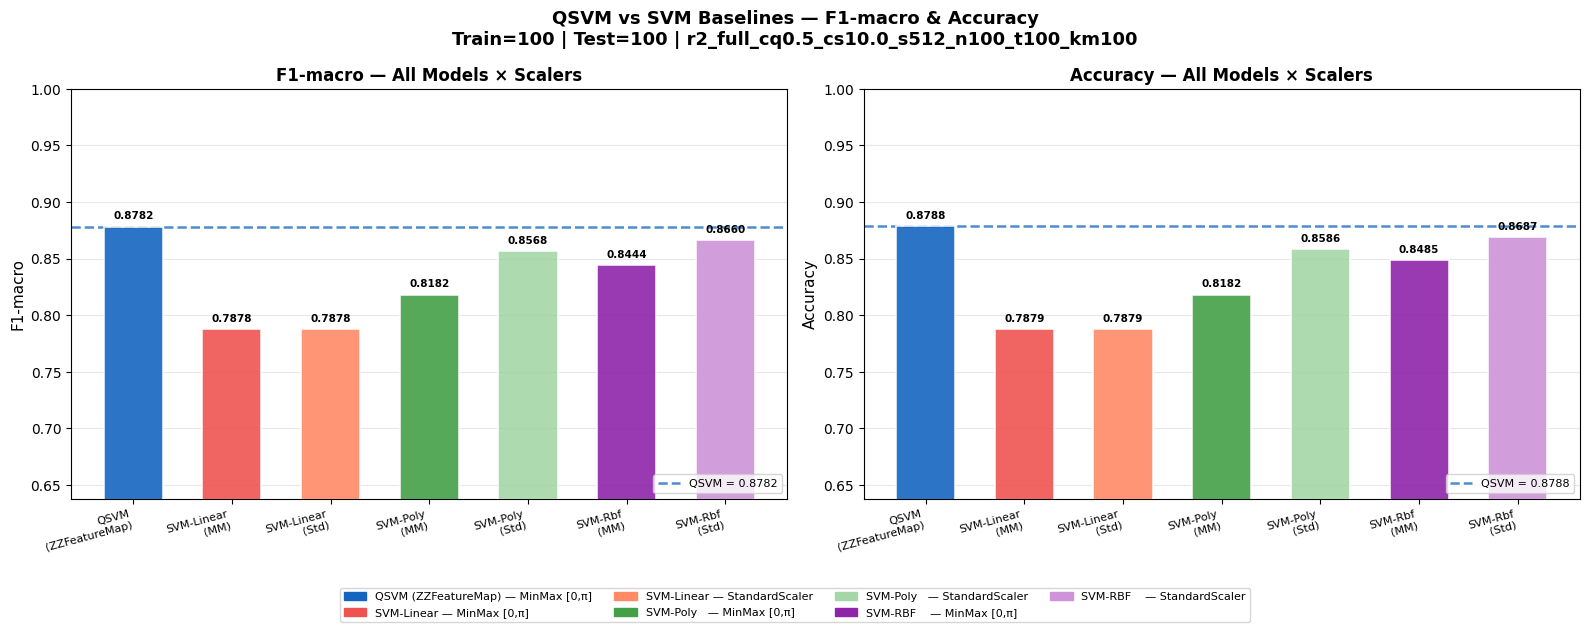

Đã lưu: ../data/processed_data/c3_performance_comparison_r2_full_cq0.5_cs10.0_s512_n100_t100_km100.png

=== DELTA vs QSVM  (QSVM F1=0.8782  Acc=0.8788) ===
  Model                                        ΔF1      ΔAcc   QSVM wins F1?
  ----------------------------------------------------------------------------
  SVM-Linear (MinMax [0,π])                +0.0904   +0.0909          ✓ QSVM
  SVM-Linear (StandardScaler)              +0.0904   +0.0909          ✓ QSVM
  SVM-Poly (MinMax [0,π])                  +0.0600   +0.0606          ✓ QSVM
  SVM-Poly (StandardScaler)                +0.0214   +0.0202          ✓ QSVM
  SVM-Rbf (MinMax [0,π])                   +0.0338   +0.0303          ✓ QSVM
  SVM-Rbf (StandardScaler)                 +0.0122   +0.0101          ✓ QSVM


In [7]:
# ── Tổng hợp tất cả kết quả vào DataFrame để so sánh ─────────────────────
comparison_rows = []

# QSVM
comparison_rows.append({
    'Model'   : 'QSVM (ZZFeatureMap)',
    'Scaler'  : 'MinMax [0,π]',
    'F1_macro': qsvm_result.get('f1',  float('nan')),
    'Accuracy': qsvm_result.get('acc', float('nan')),
    'n_SV'    : qsvm_result.get('n_sv', float('nan')),
    '_key'    : 'quantum',
    '_scaler' : 'mm',
    '_is_qsvm': True,
})

# SVM baselines — cả hai scaler
for lbl in ['linear', 'poly', 'rbf']:
    for scaler_tag, scaler_label in [('mm', 'MinMax [0,π]'), ('std', 'StandardScaler')]:
        key = f'{lbl}_{scaler_tag}'
        res = svm_results.get(key, {})
        comparison_rows.append({
            'Model'   : f'SVM-{lbl.capitalize()} ({scaler_label})',
            'Scaler'  : scaler_label,
            'F1_macro': res.get('f1',  float('nan')),
            'Accuracy': res.get('acc', float('nan')),
            'n_SV'    : res.get('n_sv', float('nan')),
            '_key'    : lbl,
            '_scaler' : scaler_tag,
            '_is_qsvm': False,
        })

cmp_df = pd.DataFrame(comparison_rows)
print("=== FULL COMPARISON TABLE ===")
print(cmp_df[['Model', 'Scaler', 'F1_macro', 'Accuracy', 'n_SV']].to_string(index=False))

# ── Figure: Bar chart F1-macro và Accuracy ───────────────────────────────
fig_cmp, axes_cmp = plt.subplots(1, 2, figsize=(16, 6))
fig_cmp.suptitle(
    f'QSVM vs SVM Baselines — F1-macro & Accuracy\n'
    f'Train={TRAIN_SIZE} | Test={TEST_SIZE} | {CONFIG_TAG}',
    fontsize=13, fontweight='bold'
)

# Màu sắc theo model type
MODEL_PALETTE = {
    'quantum'    : '#1565C0',   # QSVM — xanh đậm
    'linear_mm'  : '#EF5350',   # SVM-Linear MinMax
    'linear_std' : '#FF8A65',   # SVM-Linear Std (màu nhạt hơn)
    'poly_mm'    : '#43A047',   # SVM-Poly MinMax
    'poly_std'   : '#A5D6A7',   # SVM-Poly Std
    'rbf_mm'     : '#8E24AA',   # SVM-RBF MinMax
    'rbf_std'    : '#CE93D8',   # SVM-RBF Std
}

bar_labels  = []
bar_colors  = []
f1_vals     = []
acc_vals    = []

for _, row in cmp_df.iterrows():
    if row['_is_qsvm']:
        palette_key = 'quantum'
    else:
        palette_key = f'{row["_key"]}_{row["_scaler"]}'
    bar_colors.append(MODEL_PALETTE.get(palette_key, '#90A4AE'))
    # Short label
    if row['_is_qsvm']:
        bar_labels.append('QSVM\n(ZZFeatureMap)')
    else:
        scaler_short = 'MM' if row['_scaler'] == 'mm' else 'Std'
        bar_labels.append(f'SVM-{row["_key"].capitalize()}\n({scaler_short})')
    f1_vals.append(row['F1_macro'])
    acc_vals.append(row['Accuracy'])

x = np.arange(len(bar_labels))
BAR_W = 0.6

for ax, vals, metric_name, ylim_pad in [
    (axes_cmp[0], f1_vals,  'F1-macro',  0.15),
    (axes_cmp[1], acc_vals, 'Accuracy',  0.15),
]:
    bars = ax.bar(x, vals, BAR_W, color=bar_colors, edgecolor='white',
                  linewidth=1.2, alpha=0.90, zorder=3)

    # Giá trị trên đầu mỗi bar
    for bar, val in zip(bars, vals):
        if not np.isnan(val):
            ax.text(bar.get_x() + bar.get_width() / 2,
                    val + 0.005, f'{val:.4f}',
                    ha='center', va='bottom', fontsize=7.5, fontweight='bold')

    # Đường kẻ ngang QSVM để so sánh
    qsvm_val = f1_vals[0] if metric_name == 'F1-macro' else acc_vals[0]
    if not np.isnan(qsvm_val):
        ax.axhline(qsvm_val, color=MODEL_PALETTE['quantum'],
                   linestyle='--', linewidth=1.8, alpha=0.75, zorder=2,
                   label=f'QSVM = {qsvm_val:.4f}')
        ax.legend(fontsize=8, loc='lower right')

    ax.set_xticks(x)
    ax.set_xticklabels(bar_labels, fontsize=8, rotation=15, ha='right')
    ax.set_ylabel(metric_name, fontsize=11)
    ax.set_title(f'{metric_name} — All Models × Scalers', fontweight='bold')
    ax.grid(True, axis='y', alpha=0.3, zorder=0)

    valid_vals = [v for v in vals if not np.isnan(v)]
    if valid_vals:
        y_min = max(0, min(valid_vals) - ylim_pad)
        y_max = min(1, max(valid_vals) + ylim_pad)
        ax.set_ylim(y_min, y_max)

# Legend — màu sắc nhóm
from matplotlib.patches import Patch
legend_elems = [
    Patch(color=MODEL_PALETTE['quantum'],    label='QSVM (ZZFeatureMap) — MinMax [0,π]'),
    Patch(color=MODEL_PALETTE['linear_mm'],  label='SVM-Linear — MinMax [0,π]'),
    Patch(color=MODEL_PALETTE['linear_std'], label='SVM-Linear — StandardScaler'),
    Patch(color=MODEL_PALETTE['poly_mm'],    label='SVM-Poly   — MinMax [0,π]'),
    Patch(color=MODEL_PALETTE['poly_std'],   label='SVM-Poly   — StandardScaler'),
    Patch(color=MODEL_PALETTE['rbf_mm'],     label='SVM-RBF    — MinMax [0,π]'),
    Patch(color=MODEL_PALETTE['rbf_std'],    label='SVM-RBF    — StandardScaler'),
]
fig_cmp.legend(handles=legend_elems, loc='lower center', ncol=4,
               fontsize=8, bbox_to_anchor=(0.5, -0.05), frameon=True)

plt.tight_layout(rect=[0, 0.05, 1, 1])
fig_cmp_path = f'{OUTPUT_DIR}/c3_performance_comparison_{CONFIG_TAG}.png'
plt.savefig(fig_cmp_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Đã lưu: {fig_cmp_path}')

# ── Delta table: QSVM vs từng baseline ──────────────────────────────────
q_f1_  = cmp_df.loc[cmp_df['_is_qsvm'], 'F1_macro'].values[0]
q_acc_ = cmp_df.loc[cmp_df['_is_qsvm'], 'Accuracy'].values[0]

print()
print(f'=== DELTA vs QSVM  (QSVM F1={q_f1_:.4f}  Acc={q_acc_:.4f}) ===')
print(f'  {"Model":<38}  {"ΔF1":>8}  {"ΔAcc":>8}  {"QSVM wins F1?":>14}')
print('  ' + '-' * 76)
for _, row in cmp_df[~cmp_df['_is_qsvm']].iterrows():
    df1  = q_f1_  - row['F1_macro']
    dacc = q_acc_ - row['Accuracy']
    wins = '✓ QSVM' if df1 > 0 else ('✗ SVM' if df1 < 0 else '=')
    print(f'  {row["Model"]:<38}  {df1:>+8.4f}  {dacc:>+8.4f}  {wins:>14}')


## 6c. QSVM ZFeatureMap Training — Ablation: Không Entanglement

So sánh trực tiếp với ZZFeatureMap để trả lời: **entanglement có thực sự cần thiết không?**

| | ZZFeatureMap | ZFeatureMap |
|---|---|---|
| Cổng 2-qubit | ✅ ZZ entangle | ❌ không có |
| Encode tương tác | ✅ `2xᵢxⱼ` qua phase | ❌ chỉ `2xᵢ` đơn lẻ |
| Circuit depth | sâu hơn | shallower |
| NISQ noise | cao hơn | thấp hơn |

**Cache:** model lưu vào `qsvm_z_{CONFIG_TAG_Z}.joblib`, results lưu vào `RESULTS_CACHE_DIR_Z` — hoàn toàn tách biệt với ZZ cache.


In [8]:
# ZFeatureMap model (ablation — không entanglement)
qsvm_z_model  = None
qsvm_z_result = {}

rtag_z   = 'qsvm_z'
mpath_z  = _model_path_z('qsvm_z')
cached_z = load_result_cache(rtag_z, use_z=True)

if cached_z is not None:
    print(f'[CACHE] QSVM ZFeatureMap  F1={cached_z["f1"]:.4f}  Acc={cached_z["acc"]:.4f}')
    qsvm_z_result = cached_z
    if os.path.exists(mpath_z):
        qsvm_z_model = joblib.load(mpath_z)
        print(f'  [LOAD] ZFeatureMap model loaded từ {mpath_z}')
else:
    if os.path.exists(mpath_z):
        print('[LOAD] QSVM ZFeatureMap model từ disk ...')
        qsvm_z_model = joblib.load(mpath_z)
    else:
        print(f'[TRAIN] QSVM ZFeatureMap  [{CONFIG_TAG_Z}] ...')
        t0     = time.time()
        qk_z   = build_z_quantum_kernel()
        qsvc_z = QSVC(quantum_kernel=qk_z, C=C_QSVM_Z, random_state=RANDOM_STATE)
        qsvc_z.fit(X_train, y_train)
        joblib.dump(qsvc_z, mpath_z)
        qsvm_z_model = qsvc_z
        print(f'  Train xong: {time.time()-t0:.1f}s → saved to {mpath_z}')

    # ── Evaluate (dù load từ disk hay vừa train) ──────────────────────────
    if qsvm_z_model is not None:
        y_pred_z  = qsvm_z_model.predict(X_test)
        f1_z      = f1_score(y_test, y_pred_z, average='macro')
        acc_z     = accuracy_score(y_test, y_pred_z)
        nsv_z     = int(qsvm_z_model.n_support_.sum()) if hasattr(qsvm_z_model, 'n_support_') else 0
        svc_z_cls = qsvm_z_model.n_support_.tolist()   if hasattr(qsvm_z_model, 'n_support_') else []
        extra_z   = {'n_sv': nsv_z, 'sv_per_class': svc_z_cls, 'kernel': 'quantum_z'}
        save_result_cache(rtag_z, y_pred_z, f1_z, acc_z, extra=extra_z, use_z=True)
        qsvm_z_result = {'f1': f1_z, 'acc': acc_z, 'y_pred': y_pred_z, **extra_z}

# ── So sánh trực tiếp ZZ vs Z ─────────────────────────────────────────────
q_f1_zz  = qsvm_result.get('f1',  float('nan'))
q_acc_zz = qsvm_result.get('acc', float('nan'))
q_nsv_zz = str(qsvm_result.get('n_sv', 'N/A'))
q_f1_z   = qsvm_z_result.get('f1',  float('nan'))
q_acc_z  = qsvm_z_result.get('acc', float('nan'))
q_nsv_z  = str(qsvm_z_result.get('n_sv', 'N/A'))

print()
print('=== ABLATION: ZZFeatureMap vs ZFeatureMap (entanglement removed) ===')
print(f'  {"Model":>22}  {"F1-macro":>10}  {"Accuracy":>10}  {"n_SV":>8}')
print('  ' + '-' * 58)
print(f'  {"QSVM (ZZFeatureMap)":>22}  {q_f1_zz:>10.4f}  {q_acc_zz:>10.4f}  {q_nsv_zz:>8}')
print(f'  {"QSVM (ZFeatureMap)":>22}  {q_f1_z:>10.4f}  {q_acc_z:>10.4f}  {q_nsv_z:>8}')
delta_f1  = q_f1_zz  - q_f1_z
delta_acc = q_acc_zz - q_acc_z
print(f'  {"Δ (ZZ − Z)":>22}  {delta_f1:>+10.4f}  {delta_acc:>+10.4f}')
print()
if delta_f1 > 0.005:
    print(f'  → Entanglement giúp tăng F1 +{delta_f1:.4f}: ZZ encode tương tác cặp đặc trưng hiệu quả hơn.')
elif delta_f1 < -0.005:
    print(f'  → ZFeatureMap tốt hơn ZZ ({delta_f1:+.4f}). Xem xét lại REPS hoặc C_QSVM.')
else:
    print(f'  → Hiệu năng tương đương (|Δ|<0.005). Cần xem KTA để đánh giá kernel geometry.')

print(f'\n  ZZ model : {_model_path("qsvm_noiseless")}')
print(f'  Z  model : {mpath_z}')
print(f'  ZZ cache : {RESULTS_CACHE_DIR}')
print(f'  Z  cache : {RESULTS_CACHE_DIR_Z}')

[TRAIN] QSVM ZFeatureMap  [z_r2_cq0.5_cs10.0_s512_n100_t100_km100] ...
  Train xong: 44.4s → saved to ../models/qsvm_cache/qsvm_z_z_r2_cq0.5_cs10.0_s512_n100_t100_km100.joblib

=== ABLATION: ZZFeatureMap vs ZFeatureMap (entanglement removed) ===
                   Model    F1-macro    Accuracy      n_SV
  ----------------------------------------------------------
     QSVM (ZZFeatureMap)      0.8782      0.8788        70
      QSVM (ZFeatureMap)      0.8182      0.8182        73
              Δ (ZZ − Z)     +0.0600     +0.0606

  → Entanglement giúp tăng F1 +0.0600: ZZ encode tương tác cặp đặc trưng hiệu quả hơn.

  ZZ model : ../models/qsvm_cache/qsvm_noiseless_r2_full_cq0.5_cs10.0_s512_n100_t100_km100.joblib
  Z  model : ../models/qsvm_cache/qsvm_z_z_r2_cq0.5_cs10.0_s512_n100_t100_km100.joblib
  ZZ cache : ../models/qsvm_cache/results_c3kg_r2_full_cq0.5_cs10.0_s512_n100_t100_km100
  Z  cache : ../models/qsvm_cache/results_c3kg_z_r2_cq0.5_cs10.0_s512_n100_t100_km100


## 7. Kernel Matrix Computation & Cache

Tính Gram matrix K[i,j] = K(xᵢ, xⱼ) cho tập subsample `X_km` (stratified, ≤ KM_SAMPLE_SIZE mẫu).

**Block structure:** nếu các mẫu cùng class tập trung thành block sáng rõ ràng trên đường chéo
→ kernel phân tách class tốt hơn về mặt hình học.

Các kernel được tính: `quantum` (ZZFeatureMap), `quantum_z` (ZFeatureMap, không entanglement), `linear`, `poly`, `rbf`.

**Cache tách biệt:**
- `quantum`   → `RESULTS_CACHE_DIR/km_quantum_{CONFIG_TAG}.npz`
- `quantum_z` → `RESULTS_CACHE_DIR_Z/km_quantum_z_{CONFIG_TAG_Z}.npz`


In [9]:
from sklearn.metrics.pairwise import rbf_kernel, polynomial_kernel, linear_kernel


def compute_gram(X, label):
    """Tính Gram matrix cho X theo kernel label.
    
    label='quantum'   → ZZFeatureMap (có entanglement)
    label='quantum_z' → ZFeatureMap  (không entanglement) — ablation
    label='linear'/'poly'/'rbf' → classical kernels
    """
    if label == 'quantum':
        qk = build_quantum_kernel()
        return qk.evaluate(X)
    elif label == 'quantum_z':
        qk_z = build_z_quantum_kernel()
        return qk_z.evaluate(X)
    elif label == 'linear':
        return linear_kernel(X)
    elif label == 'poly':
        gamma_val = 1.0 / X.shape[1]
        return polynomial_kernel(X, degree=POLY_DEGREE, gamma=gamma_val, coef0=0)
    elif label == 'rbf':
        if RBF_GAMMA == 'scale':
            gamma_val = 1.0 / (X.shape[1] * X.var())
        elif RBF_GAMMA == 'auto':
            gamma_val = 1.0 / X.shape[1]
        else:
            gamma_val = float(RBF_GAMMA)
        return rbf_kernel(X, gamma=gamma_val)
    else:
        raise ValueError(f'Unknown kernel label: {label}')


# ── ZZFeatureMap kernels: cache vào RESULTS_CACHE_DIR ─────────────────────
KERNEL_LABELS_ZZ = ['quantum', 'linear', 'poly', 'rbf']
# ── ZFeatureMap kernel: cache vào RESULTS_CACHE_DIR_Z ────────────────────
KERNEL_LABELS_Z  = ['quantum_z']

km_matrices = {}   # {label: np.ndarray (n, n)} — chứa cả ZZ lẫn Z

print('=== Kernel Matrix Computation ===')
print(f'  ZZ kernels ({len(KERNEL_LABELS_ZZ)}): {KERNEL_LABELS_ZZ} → {RESULTS_CACHE_DIR}')
print(f'  Z  kernels ({len(KERNEL_LABELS_Z)}): {KERNEL_LABELS_Z} → {RESULTS_CACHE_DIR_Z}')
print()

# ── ZZ: quantum, linear, poly, rbf ────────────────────────────────────────
for label in KERNEL_LABELS_ZZ:
    cached_km = load_km_cache(label, use_z=False)
    if cached_km is not None:
        km_matrices[label] = cached_km
        print(f'  [CACHE ZZ] {label:12s} {cached_km.shape}')
        continue
    print(f'  [COMPUTE]  {label:12s} n={KM_SAMPLE_SIZE} ...', end='', flush=True)
    t0 = time.time()
    K  = compute_gram(X_km, label)
    print(f' done  {time.time()-t0:.1f}s')
    save_km_cache(label, K, use_z=False)
    km_matrices[label] = K

# ── Z: quantum_z — cache riêng trong RESULTS_CACHE_DIR_Z ──────────────────
for label in KERNEL_LABELS_Z:
    cached_km = load_km_cache(label, use_z=True)
    if cached_km is not None:
        km_matrices[label] = cached_km
        print(f'  [CACHE Z ] {label:12s} {cached_km.shape}')
        continue
    print(f'  [COMPUTE]  {label:12s} n={KM_SAMPLE_SIZE} ...', end='', flush=True)
    t0 = time.time()
    K  = compute_gram(X_km, label)
    print(f' done  {time.time()-t0:.1f}s')
    save_km_cache(label, K, use_z=True)
    km_matrices[label] = K

print()
print('Gram matrix statistics:')
print(f'{"Kernel":>12}  {"min":>8}  {"max":>8}  {"mean":>8}  {"diag_mean":>10}  {"cache"}')
print('-' * 68)
for lbl, K in km_matrices.items():
    cache_dir = RESULTS_CACHE_DIR_Z if lbl == 'quantum_z' else RESULTS_CACHE_DIR
    tag_used  = CONFIG_TAG_Z        if lbl == 'quantum_z' else CONFIG_TAG
    print(f'{lbl:>12}  {K.min():>8.4f}  {K.max():>8.4f}  {K.mean():>8.4f}  '
          f'{np.diag(K).mean():>10.4f}  km_{lbl}_{tag_used}.npz')


=== Kernel Matrix Computation ===
  ZZ kernels (4): ['quantum', 'linear', 'poly', 'rbf'] → ../models/qsvm_cache/results_c3kg_r2_full_cq0.5_cs10.0_s512_n100_t100_km100
  Z  kernels (1): ['quantum_z'] → ../models/qsvm_cache/results_c3kg_z_r2_cq0.5_cs10.0_s512_n100_t100_km100

  [COMPUTE]  quantum      n=100 ... done  100.6s
  [SAVED] kernel matrix → km_quantum_r2_full_cq0.5_cs10.0_s512_n100_t100_km100.npz  (99, 99)
  [COMPUTE]  linear       n=100 ... done  0.0s
  [SAVED] kernel matrix → km_linear_r2_full_cq0.5_cs10.0_s512_n100_t100_km100.npz  (99, 99)
  [COMPUTE]  poly         n=100 ... done  0.0s
  [SAVED] kernel matrix → km_poly_r2_full_cq0.5_cs10.0_s512_n100_t100_km100.npz  (99, 99)
  [COMPUTE]  rbf          n=100 ... done  0.0s
  [SAVED] kernel matrix → km_rbf_r2_full_cq0.5_cs10.0_s512_n100_t100_km100.npz  (99, 99)
  [COMPUTE]  quantum_z    n=100 ... done  44.1s
  [SAVED] kernel matrix → km_quantum_z_z_r2_cq0.5_cs10.0_s512_n100_t100_km100.npz  (99, 99)

Gram matrix statistics:
      

## 8. Kernel Target Alignment (KTA)

**KTA** (Cristianini et al., 2002) đo mức độ tương thích giữa cấu trúc kernel và label structure:

$$\text{KTA}(K, y) = \frac{\langle K,\, yy^\top \rangle_F}{\|K\|_F \cdot \|yy^\top\|_F}$$

KTA cao hơn → kernel geometry tương thích tốt hơn với label structure → SVM dễ tìm được hyperplane phân tách.  
KTA ∈ [−1, 1] ; giá trị > 0 là tốt, càng gần 1 càng tốt.

**So sánh chính:** `quantum` (ZZ) vs `quantum_z` (Z, không entanglement) → bằng chứng định lượng vai trò entanglement.


In [10]:
def kernel_target_alignment(K, y):
    """
    KTA = <K, yy'> / (||K||_F * ||yy'||_F).
    y: binary {0,1} — tự động chuyển sang {-1,+1}.
    """
    yy = y.astype(float).copy()
    yy[yy == 0] = -1.0
    Y   = np.outer(yy, yy)
    num = np.sum(K * Y)
    den = np.linalg.norm(K, 'fro') * np.linalg.norm(Y, 'fro')
    return float(num / den) if den > 1e-12 else 0.0


# ── KTA cache — ZZ kernels → RESULTS_CACHE_DIR ────────────────────────────
kta_cache_path    = f'{RESULTS_CACHE_DIR}/kta_{CONFIG_TAG}.json'
# ── KTA cache — Z kernel → RESULTS_CACHE_DIR_Z ───────────────────────────
kta_cache_path_z  = f'{RESULTS_CACHE_DIR_Z}/kta_z_{CONFIG_TAG_Z}.json'

# Load hoặc tính KTA cho tất cả kernels
kta_scores = {}

# ZZ kernels
if os.path.exists(kta_cache_path):
    with open(kta_cache_path) as fp:
        kta_scores_zz = json.load(fp)
    print(f'[CACHE] KTA scores ZZ loaded từ {kta_cache_path}')
else:
    kta_scores_zz = {lbl: kernel_target_alignment(km_matrices[lbl], y_km)
                     for lbl in KERNEL_LABELS_ZZ if lbl in km_matrices}
    with open(kta_cache_path, 'w') as fp:
        json.dump(kta_scores_zz, fp, indent=2)
    print(f'[SAVED] KTA ZZ → {kta_cache_path}')

kta_scores.update(kta_scores_zz)

# Z kernel (quantum_z)
if os.path.exists(kta_cache_path_z):
    with open(kta_cache_path_z) as fp:
        kta_scores_z = json.load(fp)
    print(f'[CACHE] KTA scores Z  loaded từ {kta_cache_path_z}')
else:
    kta_scores_z = {lbl: kernel_target_alignment(km_matrices[lbl], y_km)
                    for lbl in KERNEL_LABELS_Z if lbl in km_matrices}
    with open(kta_cache_path_z, 'w') as fp:
        json.dump(kta_scores_z, fp, indent=2)
    print(f'[SAVED] KTA Z  → {kta_cache_path_z}')

kta_scores.update(kta_scores_z)

# ── Print KTA ranking ─────────────────────────────────────────────────────
print()
print(f'=== Kernel Target Alignment  (n={KM_SAMPLE_SIZE} stratified samples) ===')
print(f'{"Kernel":>12}  {"KTA":>12}  {"Rank":>6}  {"Cache"}')
print('-' * 56)
sorted_kta = sorted(kta_scores.items(), key=lambda x: x[1], reverse=True)
for rank, (lbl, kta) in enumerate(sorted_kta, 1):
    marker    = '  ← best' if rank == 1 else ''
    tag_used  = CONFIG_TAG_Z if lbl == 'quantum_z' else CONFIG_TAG
    print(f'{lbl:>12}  {kta:>12.6f}  {rank:>6}{marker}  kta_{"z_" if lbl=="quantum_z" else ""}{tag_used}.json')

best_kernel  = sorted_kta[0][0]
best_kta_val = sorted_kta[0][1]
q_kta   = kta_scores.get('quantum',   float('nan'))
qz_kta  = kta_scores.get('quantum_z', float('nan'))
r_kta   = kta_scores.get('rbf',       float('nan'))
l_kta   = kta_scores.get('linear',    float('nan'))
p_kta   = kta_scores.get('poly',      float('nan'))

print()
print(f'Best kernel geometry: {best_kernel}  (KTA={best_kta_val:.6f})')
print(f'Δ KTA (ZZ − Z)      : {q_kta - qz_kta:+.6f}  ← vai trò entanglement')
print(f'Δ KTA (ZZ − linear) : {q_kta - l_kta:+.6f}')
print(f'Δ KTA (ZZ − poly)   : {q_kta - p_kta:+.6f}')
print(f'Δ KTA (ZZ − rbf)    : {q_kta - r_kta:+.6f}')

if q_kta > qz_kta:
    print(f'\n  → ZZFeatureMap KTA cao hơn ZFeatureMap (+{q_kta-qz_kta:.4f}):')
    print(f'     Entanglement cải thiện kernel geometry, phù hợp với lập luận C2.')
elif q_kta < qz_kta:
    print(f'\n  → ZFeatureMap KTA cao hơn ZZFeatureMap ({q_kta-qz_kta:+.4f}):')
    print(f'     Xem xét lại REPS hoặc ENTANGLEMENT config.')
else:
    print(f'\n  → KTA tương đương. Cần phân tích thêm decision boundary.')


[SAVED] KTA ZZ → ../models/qsvm_cache/results_c3kg_r2_full_cq0.5_cs10.0_s512_n100_t100_km100/kta_r2_full_cq0.5_cs10.0_s512_n100_t100_km100.json
[SAVED] KTA Z  → ../models/qsvm_cache/results_c3kg_z_r2_cq0.5_cs10.0_s512_n100_t100_km100/kta_z_z_r2_cq0.5_cs10.0_s512_n100_t100_km100.json

=== Kernel Target Alignment  (n=100 stratified samples) ===
      Kernel           KTA    Rank  Cache
--------------------------------------------------------
         rbf      0.289659       1  ← best  kta_r2_full_cq0.5_cs10.0_s512_n100_t100_km100.json
     quantum      0.215365       2  kta_r2_full_cq0.5_cs10.0_s512_n100_t100_km100.json
        poly      0.131643       3  kta_r2_full_cq0.5_cs10.0_s512_n100_t100_km100.json
   quantum_z      0.075787       4  kta_z_z_r2_cq0.5_cs10.0_s512_n100_t100_km100.json
      linear      0.065091       5  kta_r2_full_cq0.5_cs10.0_s512_n100_t100_km100.json

Best kernel geometry: rbf  (KTA=0.289659)
Δ KTA (ZZ − Z)      : +0.139578  ← vai trò entanglement
Δ KTA (ZZ − lin

## 9. Support Vector Distribution & Margin Analysis

Phân tích:
- Số lượng Support Vectors và tỷ lệ SV/train per class (Normal vs Attack)
- Distribution của functional margin |decision_function(x)| trên toàn train set
- Margin rộng hơn → classifier tổng quát hóa tốt hơn

In [11]:
sv_analysis = {}   # {label: {n_sv, sv_ratio, sv_class_dist, margin_mean, margin_std}}

# ── Định nghĩa cache paths TRƯỚC khi dùng ─────────────────────────────────
sv_cache_path   = f'{RESULTS_CACHE_DIR}/sv_analysis_{CONFIG_TAG}.json'
sv_cache_path_z = f'{RESULTS_CACHE_DIR_Z}/sv_analysis_z_{CONFIG_TAG_Z}.json'
zz_sv_labels    = ['quantum', 'linear', 'poly', 'rbf']
z_sv_labels     = ['quantum_z']

# ── Load cache nếu đã có ──────────────────────────────────────────────────
_zz_loaded, _z_loaded = False, False

if os.path.exists(sv_cache_path):
    with open(sv_cache_path) as fp:
        sv_analysis.update(json.load(fp))
    print(f'[CACHE] SV analysis ZZ loaded → {list(sv_analysis.keys())}')
    _zz_loaded = True

if os.path.exists(sv_cache_path_z):
    with open(sv_cache_path_z) as fp:
        sv_analysis.update(json.load(fp))
    print(f'[CACHE] SV analysis Z  loaded → {[k for k in sv_analysis if k in z_sv_labels]}')
    _z_loaded = True

# ── Compute nếu chưa có cache ─────────────────────────────────────────────
if not _zz_loaded:
    print('[COMPUTE] SV analysis ZZ (QSVM + Classical) ...')

    # QSVM ZZFeatureMap
    if qsvm_model is not None and hasattr(qsvm_model, 'support_'):
        sv_idx  = qsvm_model.support_
        df_vals = qsvm_model.decision_function(X_train)
        sv_analysis['quantum'] = {
            'n_sv'          : int(len(sv_idx)),
            'sv_per_class'  : qsvm_model.n_support_.tolist(),
            'sv_ratio'      : float(len(sv_idx) / TRAIN_SIZE),
            'margin_mean'   : float(np.abs(df_vals).mean()),
            'margin_std'    : float(np.abs(df_vals).std()),
            'sv_class_dist' : np.bincount(y_train[sv_idx], minlength=2).tolist(),
            'df_scores'     : df_vals.tolist(),
        }
        print(f'  [DONE] quantum  n_SV={sv_analysis["quantum"]["n_sv"]}')

    # SVM Classical
    for lbl, svc in svm_models.items():
        if svc is None:
            continue
        sv_idx  = svc.support_
        df_vals = svc.decision_function(X_train)
        sv_analysis[lbl] = {
            'n_sv'          : int(len(sv_idx)),
            'sv_per_class'  : svc.n_support_.tolist(),
            'sv_ratio'      : float(len(sv_idx) / TRAIN_SIZE),
            'margin_mean'   : float(np.abs(df_vals).mean()),
            'margin_std'    : float(np.abs(df_vals).std()),
            'sv_class_dist' : np.bincount(y_train[sv_idx], minlength=2).tolist(),
            'df_scores'     : df_vals.tolist(),
        }
        print(f'  [DONE] {lbl:12s} n_SV={sv_analysis[lbl]["n_sv"]}')

    # Lưu cache ZZ (bao gồm df_scores để dùng ở cell sau)
    sv_save = {k: v for k, v in sv_analysis.items() if k in zz_sv_labels}
    with open(sv_cache_path, 'w') as fp:
        json.dump(sv_save, fp, indent=2)
    print(f'[SAVED] SV analysis ZZ → {sv_cache_path}')

if not _z_loaded:
    print('[COMPUTE] SV analysis Z (ZFeatureMap ablation) ...')

    # QSVM ZFeatureMap
    if qsvm_z_model is not None and hasattr(qsvm_z_model, 'support_'):
        sv_idx_z  = qsvm_z_model.support_
        df_vals_z = qsvm_z_model.decision_function(X_train)
        sv_analysis['quantum_z'] = {
            'n_sv'          : int(len(sv_idx_z)),
            'sv_per_class'  : qsvm_z_model.n_support_.tolist(),
            'sv_ratio'      : float(len(sv_idx_z) / TRAIN_SIZE),
            'margin_mean'   : float(np.abs(df_vals_z).mean()),
            'margin_std'    : float(np.abs(df_vals_z).std()),
            'sv_class_dist' : np.bincount(y_train[sv_idx_z], minlength=2).tolist(),
            'df_scores'     : df_vals_z.tolist(),
        }
        print(f'  [DONE] quantum_z  n_SV={sv_analysis["quantum_z"]["n_sv"]}')

    # Lưu cache Z
    sv_save_z = {k: v for k, v in sv_analysis.items() if k in z_sv_labels}
    with open(sv_cache_path_z, 'w') as fp:
        json.dump(sv_save_z, fp, indent=2)
    print(f'[SAVED] SV analysis Z  → {sv_cache_path_z}')

# ── df_scores: convert list → np.array sau khi load từ JSON ──────────────
# JSON lưu list, nhưng các cell sau cần np.array để tính toán
for lbl in sv_analysis:
    if 'df_scores' in sv_analysis[lbl] and isinstance(sv_analysis[lbl]['df_scores'], list):
        sv_analysis[lbl]['df_scores'] = np.array(sv_analysis[lbl]['df_scores'])

# ── Print summary ─────────────────────────────────────────────────────────
print()
print(f'=== Support Vector Summary  (train={TRAIN_SIZE}) ===')
hdr = f'{"Kernel":>10}  {"n_SV":>6}  {"SV%":>6}  {"SV cls0":>8}  {"SV cls1":>8}  {"Margin μ":>10}  {"Margin σ":>10}'
print(hdr)
print('-' * 76)
for lbl in ['quantum', 'quantum_z', 'linear', 'poly', 'rbf']:
    info = sv_analysis.get(lbl)
    if info is None:
        continue
    sv0, sv1 = info['sv_class_dist']
    print(f'{lbl:>10}  {info["n_sv"]:>6}  {info["sv_ratio"]*100:>5.1f}%  '
          f'{sv0:>8}  {sv1:>8}  {info["margin_mean"]:>10.4f}  {info["margin_std"]:>10.4f}')

[COMPUTE] SV analysis ZZ (QSVM + Classical) ...
  [DONE] quantum  n_SV=70
  [DONE] linear_mm    n_SV=37
  [DONE] linear_std   n_SV=37
  [DONE] poly_mm      n_SV=36
  [DONE] poly_std     n_SV=30
  [DONE] rbf_mm       n_SV=34
  [DONE] rbf_std      n_SV=34
  [DONE] linear       n_SV=37
  [DONE] poly         n_SV=36
  [DONE] rbf          n_SV=34
[SAVED] SV analysis ZZ → ../models/qsvm_cache/results_c3kg_r2_full_cq0.5_cs10.0_s512_n100_t100_km100/sv_analysis_r2_full_cq0.5_cs10.0_s512_n100_t100_km100.json
[COMPUTE] SV analysis Z (ZFeatureMap ablation) ...
  [DONE] quantum_z  n_SV=73
[SAVED] SV analysis Z  → ../models/qsvm_cache/results_c3kg_z_r2_cq0.5_cs10.0_s512_n100_t100_km100/sv_analysis_z_z_r2_cq0.5_cs10.0_s512_n100_t100_km100.json

=== Support Vector Summary  (train=100) ===
    Kernel    n_SV     SV%   SV cls0   SV cls1    Margin μ    Margin σ
----------------------------------------------------------------------------
   quantum      70   70.0%        34        36      0.8509      0.28

## 10. Decision Boundary Projection (4D → 2D)

Chiếu biên quyết định 4D về 2D:
- **PC1 vs PC2** — hai PC giải thích nhiều phương sai nhất
- **PC3 vs PC4** — hai PC còn lại

Với mỗi cặp PC, các chiều còn lại được giữ ở **giá trị median** của tập train.
Grid resolution = 60×60 (đủ mịn để thấy độ cong boundary).

In [12]:
import numpy as np
import time
import os

def boundary_grid_fast(X, model, pc_pair=(0, 1), n_grid=30, batch_size=50):
    medians      = np.median(X, axis=0)
    i, j         = pc_pair
    x_min, x_max = X[:, i].min() - 0.05, X[:, i].max() + 0.05
    y_min, y_max = X[:, j].min() - 0.05, X[:, j].max() + 0.05

    xx, yy = np.meshgrid(np.linspace(x_min, x_max, n_grid),
                         np.linspace(y_min, y_max, n_grid))
    pts       = np.tile(medians, (xx.ravel().shape[0], 1))
    pts[:, i] = xx.ravel()
    pts[:, j] = yy.ravel()

    Z_flat = []
    for start in range(0, len(pts), batch_size):
        batch = pts[start : start + batch_size]
        try:
            preds = np.sign(model.decision_function(batch)).astype(int)
        except AttributeError:
            preds = model.predict(batch)
        Z_flat.extend(preds)

    return xx, yy, np.array(Z_flat).reshape(xx.shape)


# ── CONFIG — đổi n_grid ở đây, cache tự động tạo tên mới ─────────────────────
N_GRID_QUANTUM   = 20
N_GRID_CLASSICAL = 40

# Cache tách biệt: quantum và classical có tên file encode n_grid riêng
# → đổi N_GRID_CLASSICAL không bao giờ đụng cache quantum và ngược lại
_db_cache_q  = f'{RESULTS_CACHE_DIR}/db_quantum_g{N_GRID_QUANTUM}_{CONFIG_TAG}.npz'
_db_cache_cl = f'{RESULTS_CACHE_DIR}/db_classical_g{N_GRID_CLASSICAL}_{CONFIG_TAG}.npz'

_QUANTUM_LBLS   = ['quantum', 'quantum_z']
_CLASSICAL_LBLS = ['linear', 'poly', 'rbf']

# ── Load / Compute theo từng nhóm ─────────────────────────────────────────────
db_grids = {}   # dict này được dùng bởi tất cả các cell visualization bên dưới

for _cache_path, _labels, _is_quantum in [
    (_db_cache_q,  _QUANTUM_LBLS,   True),
    (_db_cache_cl, _CLASSICAL_LBLS, False),
]:
    # ── Load nếu cache đã có ──────────────────────────────────────────────
    if os.path.exists(_cache_path):
        _db   = np.load(_cache_path, allow_pickle=True)
        _dict = {k: _db[k] for k in _db.files}
        for lbl in _labels:
            db_grids[lbl] = {}
            for pname in ['pc12', 'pc34']:
                if f'{lbl}_{pname}_xx' in _dict:
                    db_grids[lbl][pname] = {
                        'xx': _dict[f'{lbl}_{pname}_xx'],
                        'yy': _dict[f'{lbl}_{pname}_yy'],
                        'Z' : _dict[f'{lbl}_{pname}_Z'],
                    }
        _tag = 'quantum' if _is_quantum else 'classical'
        print(f'[CACHE] {_tag} (g={N_GRID_QUANTUM if _is_quantum else N_GRID_CLASSICAL}) '
              f'← {os.path.basename(_cache_path)}')
        continue

    # ── Compute nếu chưa có cache ─────────────────────────────────────────
    _n_grid = N_GRID_QUANTUM if _is_quantum else N_GRID_CLASSICAL
    _b_size = 25             if _is_quantum else 500
    _model_dict = (
        {'quantum': qsvm_model, 'quantum_z': qsvm_z_model}
        if _is_quantum else
        {k: svm_models[k] for k in _CLASSICAL_LBLS if k in svm_models}
    )
    _tag = 'quantum' if _is_quantum else 'classical'
    print(f'[COMPUTE] {_tag}  grid={_n_grid}²  batch={_b_size} ...')

    _flat = {}
    for lbl, model in _model_dict.items():
        if model is None:
            print(f'  [SKIP] {lbl}: model not available')
            continue
        db_grids[lbl] = {}
        for pname, pc_pair in [('pc12', (0, 1)), ('pc34', (2, 3))]:
            t0        = time.time()
            xx, yy, Z = boundary_grid_fast(
                X_train, model, pc_pair=pc_pair,
                n_grid=_n_grid, batch_size=_b_size
            )
            db_grids[lbl][pname]      = {'xx': xx, 'yy': yy, 'Z': Z}
            _flat[f'{lbl}_{pname}_xx'] = xx
            _flat[f'{lbl}_{pname}_yy'] = yy
            _flat[f'{lbl}_{pname}_Z']  = Z
            print(f'  {lbl:12s} {pname}  {time.time()-t0:.1f}s')

    np.savez_compressed(_cache_path, **_flat)
    print(f'[SAVED] → {os.path.basename(_cache_path)}')

print('\nDecision boundary grids ready:', list(db_grids.keys()))
print(f'  quantum cache  : {os.path.basename(_db_cache_q)}')
print(f'  classical cache: {os.path.basename(_db_cache_cl)}')

[COMPUTE] quantum  grid=20²  batch=25 ...
  quantum      pc12  497.4s
  quantum      pc34  497.5s
  quantum_z    pc12  228.6s
  quantum_z    pc34  228.4s
[SAVED] → db_quantum_g20_r2_full_cq0.5_cs10.0_s512_n100_t100_km100.npz
[COMPUTE] classical  grid=40²  batch=500 ...
  linear       pc12  0.0s
  linear       pc34  0.0s
  poly         pc12  0.0s
  poly         pc34  0.0s
  rbf          pc12  0.0s
  rbf          pc34  0.0s
[SAVED] → db_classical_g40_r2_full_cq0.5_cs10.0_s512_n100_t100_km100.npz

Decision boundary grids ready: ['quantum', 'quantum_z', 'linear', 'poly', 'rbf']
  quantum cache  : db_quantum_g20_r2_full_cq0.5_cs10.0_s512_n100_t100_km100.npz
  classical cache: db_classical_g40_r2_full_cq0.5_cs10.0_s512_n100_t100_km100.npz


## 11. Spearman Correlation Validation

Xác nhận rằng các PC có tương quan **phi tuyến** (phát hiện ở C1) được ZZFeatureMap khai thác
thông qua entanglement gate ZZ — chuỗi bằng chứng nhất quán **C1→C2→C3**.

- **Pearson** ≈ 0 (expected, PCA orthogonal về mặt tuyến tính)
- **Spearman** ≠ 0 → tương quan rank-order phi tuyến mà linear SVM bỏ sót
- ZZFeatureMap encode `2xᵢxⱼ` cross-term → khai thác đúng cấu trúc này

In [13]:
# Tính Pearson và Spearman trên PCA output (pre-MinMax scaler)
pearson_matrix  = np.corrcoef(X_train_pca.T)
spearman_matrix = np.zeros((N_QUBITS, N_QUBITS))
for i in range(N_QUBITS):
    for j in range(N_QUBITS):
        r, _ = spearmanr(X_train_pca[:, i], X_train_pca[:, j])
        spearman_matrix[i, j] = r

corr_cache_path = f'{RESULTS_CACHE_DIR}/correlations_{CONFIG_TAG}.npz'
if not os.path.exists(corr_cache_path):
    np.savez_compressed(corr_cache_path,
                        pearson=pearson_matrix,
                        spearman=spearman_matrix)
    print(f'[SAVED] Correlation matrices → {corr_cache_path}')

print('=== Pearson Correlation Matrix (PCA output, pre-MinMax) ===')
print(pd.DataFrame(pearson_matrix, index=PC_LABELS, columns=PC_LABELS).round(4).to_string())

print('\n=== Spearman Correlation Matrix ===')
print(pd.DataFrame(spearman_matrix, index=PC_LABELS, columns=PC_LABELS).round(4).to_string())

print('\nCác cặp PC có |Spearman| > 0.10 (ZZFeatureMap có thể khai thác):')
threshold = 0.10
found_any = False
for i in range(N_QUBITS):
    for j in range(i + 1, N_QUBITS):
        sp = spearman_matrix[i, j]
        pe = pearson_matrix[i, j]
        if abs(sp) > threshold:
            found_any = True
            print(f'  {PC_LABELS[i]}–{PC_LABELS[j]}: '
                  f'Pearson={pe:+.4f}  Spearman={sp:+.4f}  '
                  f'nonlinear excess={abs(sp)-abs(pe):+.4f}')
if not found_any:
    print('  (Không có cặp nào vượt ngưỡng 0.10 — correlations yếu ở config này)')

[SAVED] Correlation matrices → ../models/qsvm_cache/results_c3kg_r2_full_cq0.5_cs10.0_s512_n100_t100_km100/correlations_r2_full_cq0.5_cs10.0_s512_n100_t100_km100.npz
=== Pearson Correlation Matrix (PCA output, pre-MinMax) ===
        PC1     PC2     PC3     PC4
PC1  1.0000  0.0940 -0.0060 -0.0477
PC2  0.0940  1.0000  0.0771  0.0453
PC3 -0.0060  0.0771  1.0000  0.2801
PC4 -0.0477  0.0453  0.2801  1.0000

=== Spearman Correlation Matrix ===
        PC1     PC2     PC3     PC4
PC1  1.0000  0.0909  0.2895  0.0574
PC2  0.0909  1.0000 -0.4159 -0.2205
PC3  0.2895 -0.4159  1.0000  0.4581
PC4  0.0574 -0.2205  0.4581  1.0000

Các cặp PC có |Spearman| > 0.10 (ZZFeatureMap có thể khai thác):
  PC1–PC3: Pearson=-0.0060  Spearman=+0.2895  nonlinear excess=+0.2836
  PC2–PC3: Pearson=+0.0771  Spearman=-0.4159  nonlinear excess=+0.3388
  PC2–PC4: Pearson=+0.0453  Spearman=-0.2205  nonlinear excess=+0.1753
  PC3–PC4: Pearson=+0.2801  Spearman=+0.4581  nonlinear excess=+0.1779


## 12. Visualization Tổng Hợp — Figure 1: Overview

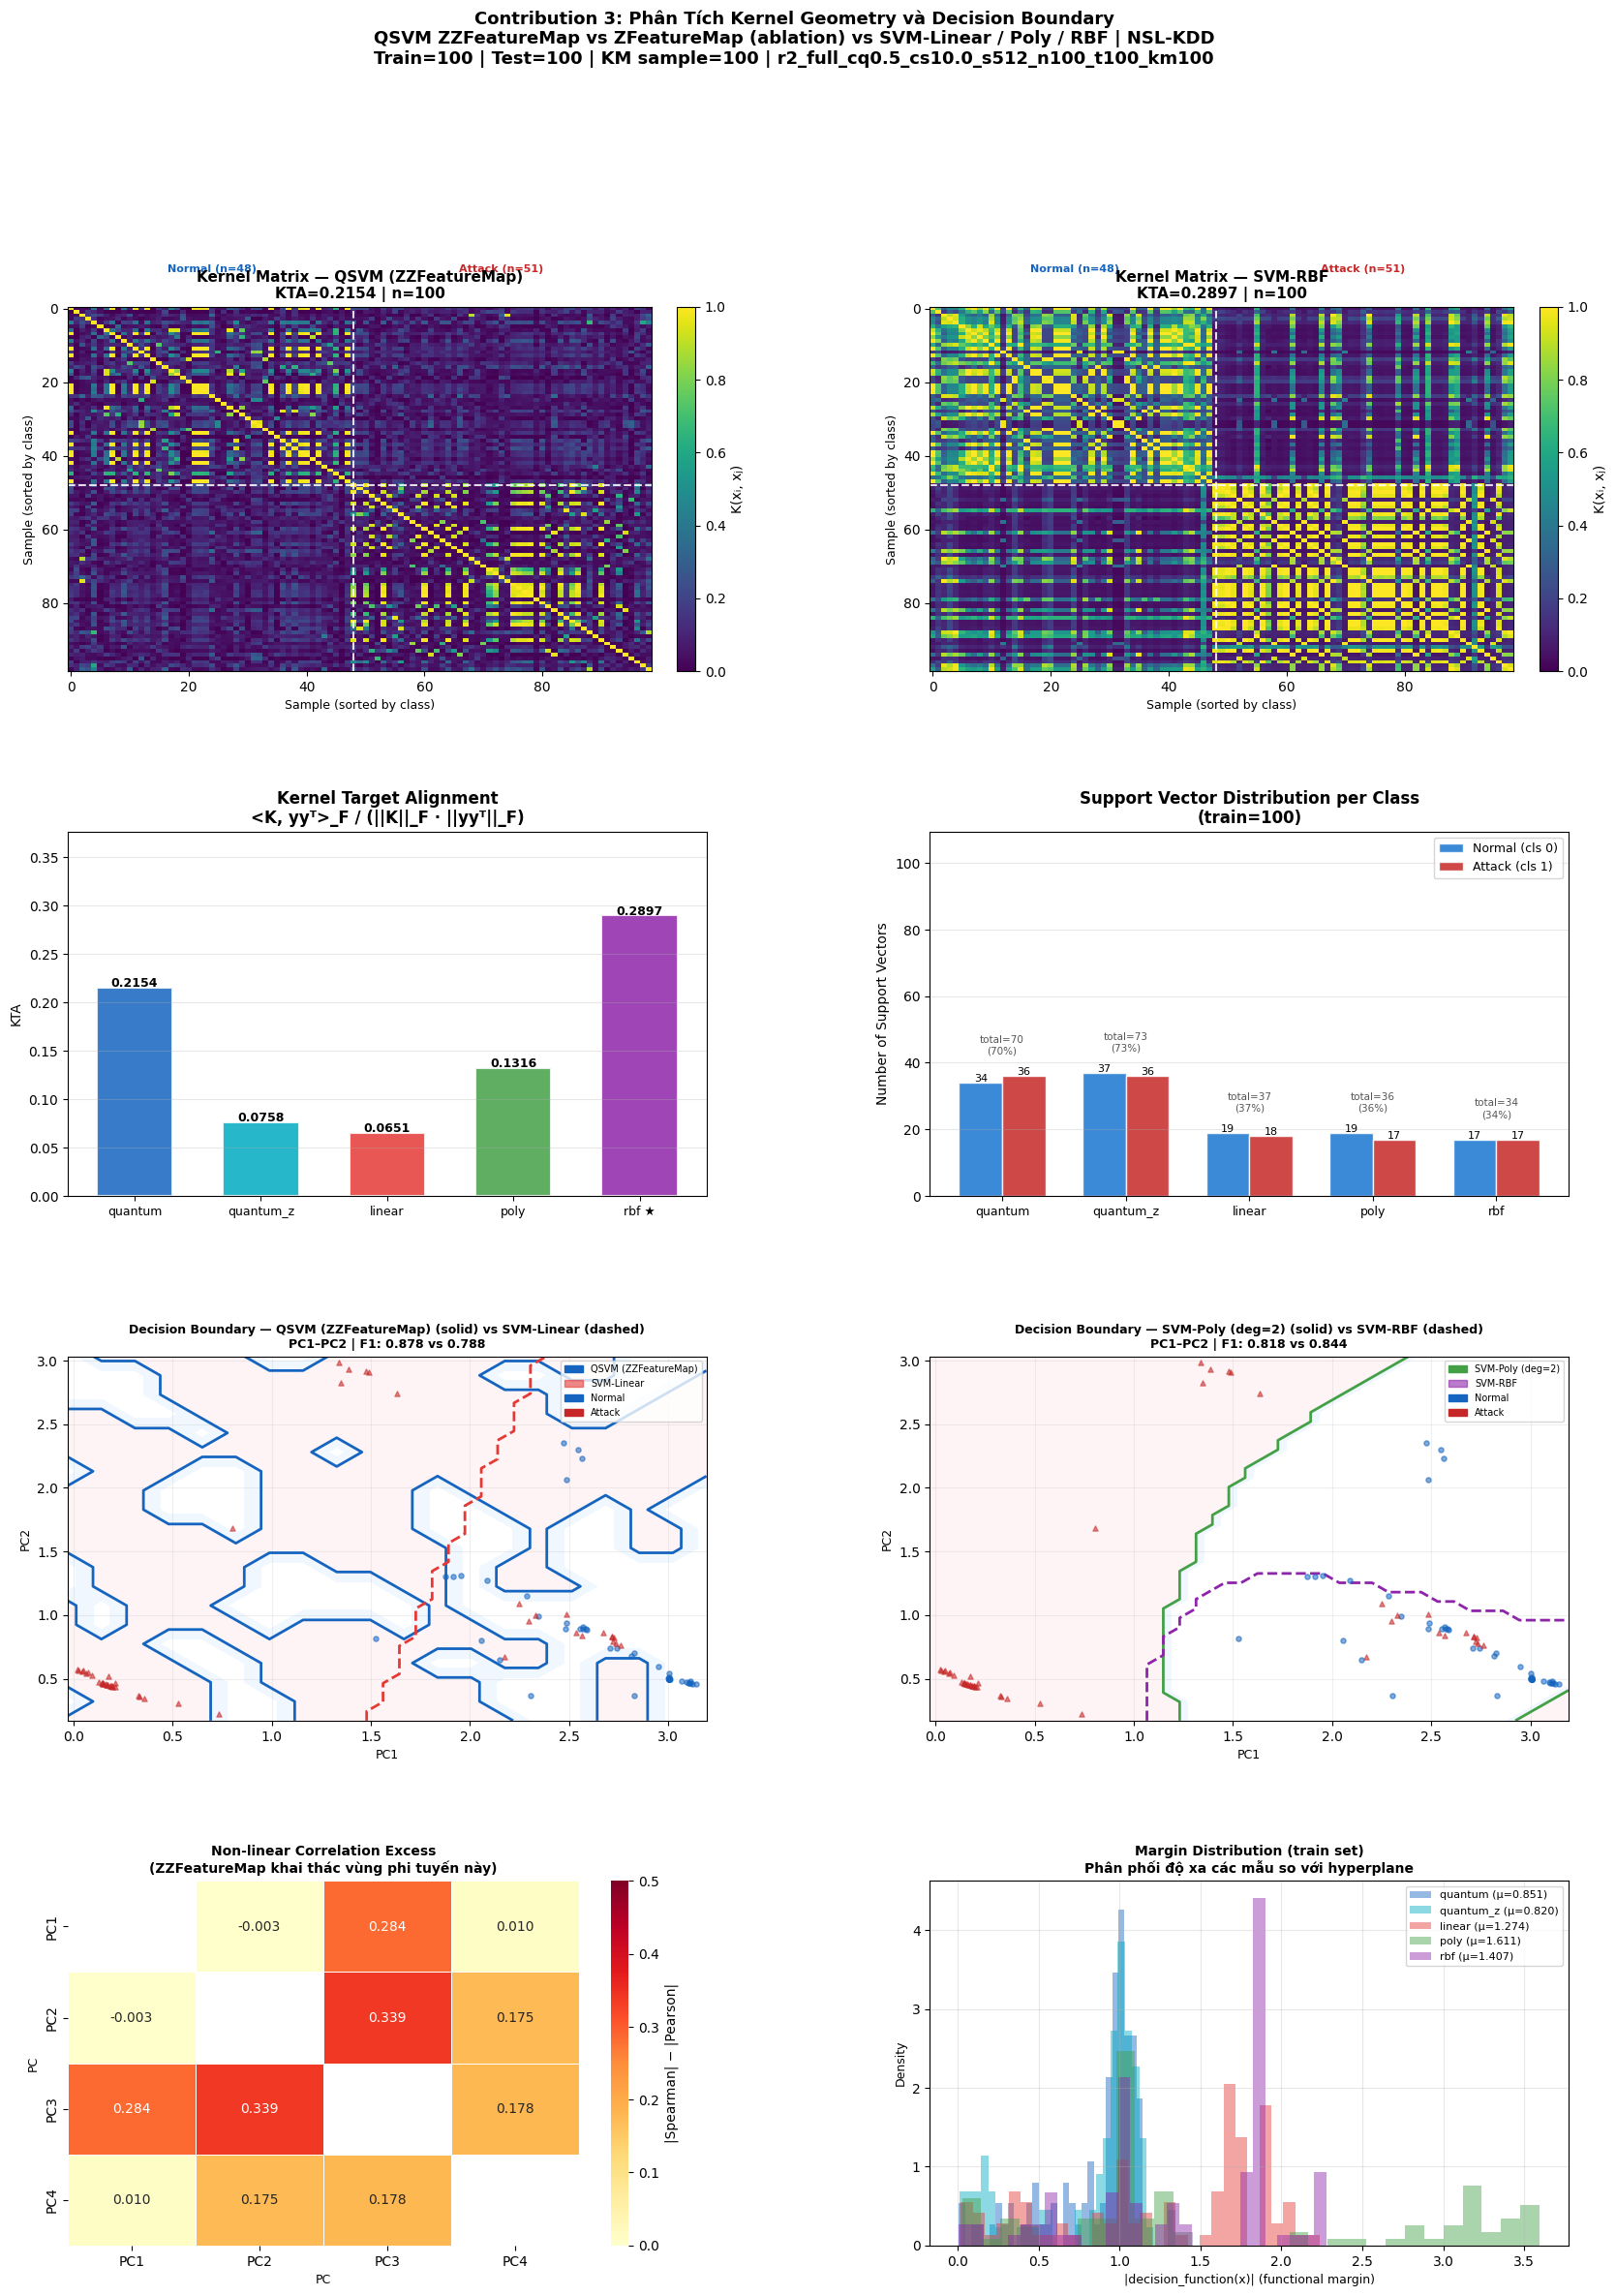

Đã lưu: ../data/processed_data/c3_kernel_geometry_r2_full_cq0.5_cs10.0_s512_n100_t100_km100.png


In [14]:
COLORS = {
    'quantum':   '#1565C0',   # QSVM ZZFeatureMap — xanh đậm
    'quantum_z': '#00ACC1',   # QSVM ZFeatureMap  — xanh cyan (ablation)
    'linear':    '#E53935',
    'poly':      '#43A047',
    'rbf':       '#8E24AA',
}
LABEL_NAMES = {
    'quantum':   'QSVM (ZZFeatureMap)',
    'quantum_z': 'QSVM (ZFeatureMap, no entangle)',
    'linear':    'SVM-Linear',
    'poly':      f'SVM-Poly (deg={POLY_DEGREE})',
    'rbf':       'SVM-RBF',
}

# Sort index của X_km theo class để block structure rõ hơn
sort_idx  = np.argsort(y_km)
y_km_s    = y_km[sort_idx]
boundary  = int(np.where(np.diff(y_km_s))[0][0]) + 1

fig = plt.figure(figsize=(20, 26))
gs  = gridspec.GridSpec(4, 2, figure=fig, hspace=0.44, wspace=0.35)
fig.suptitle(
    'Contribution 3: Phân Tích Kernel Geometry và Decision Boundary\n'
    f'QSVM ZZFeatureMap vs ZFeatureMap (ablation) vs SVM-Linear / Poly / RBF | NSL-KDD\n'
    f'Train={TRAIN_SIZE} | Test={TEST_SIZE} | KM sample={KM_SAMPLE_SIZE} | {CONFIG_TAG}',
    fontsize=13, fontweight='bold', y=0.998
)

# ── Row 1: Kernel matrix heatmap — Quantum vs RBF (representative pair) ──
for col_idx, km_lbl in enumerate(['quantum', 'rbf']):
    ax  = fig.add_subplot(gs[0, col_idx])
    K   = km_matrices[km_lbl][sort_idx][:, sort_idx]
    im  = ax.imshow(K, aspect='auto', cmap='viridis',
                    vmin=0, vmax=1, interpolation='nearest')
    ax.axhline(boundary, color='white', lw=1.5, ls='--', alpha=0.85)
    ax.axvline(boundary, color='white', lw=1.5, ls='--', alpha=0.85)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='K(xᵢ, xⱼ)')
    kta_v = kta_scores.get(km_lbl, float('nan'))
    ax.set_title(f'Kernel Matrix — {LABEL_NAMES[km_lbl]}\nKTA={kta_v:.4f} | n={KM_SAMPLE_SIZE}',
                 fontweight='bold', fontsize=11)
    ax.set_xlabel('Sample (sorted by class)', fontsize=9)
    ax.set_ylabel('Sample (sorted by class)', fontsize=9)
    n0 = int(np.sum(y_km_s == 0))
    n1 = int(np.sum(y_km_s == 1))
    ax.text(n0 // 2,      -10, f'Normal (n={n0})',  ha='center', fontsize=8,
            color='#1565C0', fontweight='bold', clip_on=False)
    ax.text(n0 + n1 // 2, -10, f'Attack (n={n1})',  ha='center', fontsize=8,
            color='#C62828', fontweight='bold', clip_on=False)

# ── Row 2: KTA bar + SV distribution ──────────────────────────────────────
ax3     = fig.add_subplot(gs[1, 0])
kta_lbs = ['quantum', 'quantum_z', 'linear', 'poly', 'rbf']
kta_vs  = [kta_scores.get(l, float('nan')) for l in kta_lbs]
bars    = ax3.bar(kta_lbs, kta_vs,
                  color=[COLORS[l] for l in kta_lbs],
                  alpha=0.85, edgecolor='white', linewidth=1.5, width=0.6)
for bar, val in zip(bars, kta_vs):
    ax3.text(bar.get_x() + bar.get_width() / 2, val + 0.001,
             f'{val:.4f}', ha='center', fontsize=9, fontweight='bold')
_best_lbl = kta_lbs[int(np.argmax(kta_vs))]
ax3.set_xticklabels([f'{l} ★' if l == _best_lbl else l for l in kta_lbs], fontsize=9)
ax3.set_ylabel('KTA', fontsize=10)
ax3.set_title('Kernel Target Alignment\n<K, yyᵀ>_F / (||K||_F · ||yyᵀ||_F)',
              fontweight='bold')
ax3.set_ylim(0, max(kta_vs) * 1.30 if kta_vs else 1)
ax3.grid(True, axis='y', alpha=0.3)

ax4   = fig.add_subplot(gs[1, 1])
sv_lb = [l for l in ['quantum', 'quantum_z', 'linear', 'poly', 'rbf'] if l in sv_analysis]
sv_n0 = [sv_analysis[l]['sv_class_dist'][0] for l in sv_lb]
sv_n1 = [sv_analysis[l]['sv_class_dist'][1] for l in sv_lb]
sv_nt = [sv_analysis[l]['n_sv']             for l in sv_lb]
x_sv  = np.arange(len(sv_lb))
w_sv  = 0.35
b0 = ax4.bar(x_sv - w_sv / 2, sv_n0, w_sv, label='Normal (cls 0)',
             color='#1976D2', alpha=0.85, edgecolor='white')
b1 = ax4.bar(x_sv + w_sv / 2, sv_n1, w_sv, label='Attack (cls 1)',
             color='#C62828', alpha=0.85, edgecolor='white')
for bar, val in zip(list(b0) + list(b1), sv_n0 + sv_n1):
    ax4.text(bar.get_x() + bar.get_width() / 2, val + 0.3,
             str(val), ha='center', fontsize=8)
for i, (tot, pct) in enumerate(zip(sv_nt, [t / TRAIN_SIZE * 100 for t in sv_nt])):
    ax4.text(i, max(sv_n0[i], sv_n1[i]) + max(sv_nt) * 0.09,
             f'total={tot}\n({pct:.0f}%)', ha='center', fontsize=7.5, color='#555')
ax4.set_xticks(x_sv)
ax4.set_xticklabels(sv_lb, fontsize=9)
ax4.set_ylabel('Number of Support Vectors', fontsize=10)
ax4.set_title(f'Support Vector Distribution per Class\n(train={TRAIN_SIZE})',
              fontweight='bold')
ax4.legend(fontsize=9)
ax4.grid(True, axis='y', alpha=0.3)
ax4.set_ylim(0, max(sv_nt) * 1.5)

# ── Row 3: Decision boundary PC1–PC2 — Quantum & Linear (left), Poly & RBF (right) ──
PC_PAIR_INFO = [
    ('pc12', 0, 1, 'PC1', 'PC2'),
    ('pc34', 2, 3, 'PC3', 'PC4'),
]
pairs_row3 = [('quantum', 'linear'), ('poly', 'rbf')]

for col_idx, (lbl_a, lbl_b) in enumerate(pairs_row3):
    ax = fig.add_subplot(gs[2, col_idx])
    _pair, _i, _j, _xl, _yl = PC_PAIR_INFO[0]   # PC1–PC2
    for _lbl, _linestyle, _alpha_fill in [(lbl_a, 'solid', 0.22), (lbl_b, 'dashed', 0.0)]:
        if _lbl not in db_grids:
            continue
        g = db_grids[_lbl][_pair]
        if _alpha_fill > 0:
            ax.contourf(g['xx'], g['yy'], g['Z'], alpha=_alpha_fill,
                        levels=[-0.5, 0.5, 1.5], colors=['#BBDEFB', '#FFCDD2'])
        ax.contour(g['xx'], g['yy'], g['Z'], levels=[0.5],
                   colors=[COLORS[_lbl]], linewidths=2.0, linestyles=_linestyle)
    for cls, marker, color in [(0, 'o', '#1565C0'), (1, '^', '#C62828')]:
        mask = y_train == cls
        ax.scatter(X_train[mask, _i], X_train[mask, _j],
                   c=color, marker=marker, s=14, alpha=0.55, zorder=3)
    handles_db = [
        mpatches.Patch(color=COLORS[lbl_a], label=LABEL_NAMES[lbl_a]),
        mpatches.Patch(color=COLORS[lbl_b], label=LABEL_NAMES[lbl_b], alpha=0.6),
        mpatches.Patch(color='#1565C0', label='Normal'),
        mpatches.Patch(color='#C62828', label='Attack'),
    ]
    ax.legend(handles=handles_db, fontsize=7, loc='upper right')
    f1_a = qsvm_result.get('f1', float('nan')) if lbl_a == 'quantum' else svm_results.get(lbl_a, {}).get('f1', float('nan'))
    f1_b = svm_results.get(lbl_b, {}).get('f1', float('nan'))
    ax.set_title(f'Decision Boundary — {LABEL_NAMES[lbl_a]} (solid) vs {LABEL_NAMES[lbl_b]} (dashed)\n'
                 f'{_xl}–{_yl} | F1: {f1_a:.3f} vs {f1_b:.3f}',
                 fontweight='bold', fontsize=9)
    ax.set_xlabel(_xl, fontsize=9); ax.set_ylabel(_yl, fontsize=9)
    ax.grid(True, alpha=0.2)

# ── Row 4: Spearman delta heatmap + Margin distribution histogram ──────────
ax_sp = fig.add_subplot(gs[3, 0])
delta_corr = np.abs(spearman_matrix) - np.abs(pearson_matrix)
np.fill_diagonal(delta_corr, 0)
mask_diag  = np.eye(N_QUBITS, dtype=bool)
sns.heatmap(delta_corr, annot=True, fmt='.3f', cmap='YlOrRd',
            vmin=0, vmax=max(0.5, delta_corr.max()),
            xticklabels=PC_LABELS, yticklabels=PC_LABELS,
            linewidths=0.5, mask=mask_diag, ax=ax_sp,
            cbar_kws={'label': '|Spearman| − |Pearson|'})
ax_sp.set_title('Non-linear Correlation Excess\n'
                '(ZZFeatureMap khai thác vùng phi tuyến này)',
                fontweight='bold', fontsize=10)
ax_sp.set_xlabel('PC', fontsize=9); ax_sp.set_ylabel('PC', fontsize=9)

ax_mg = fig.add_subplot(gs[3, 1])
mg_colors = {
    'quantum'  : '#1565C0',
    'quantum_z': '#00ACC1', 
    'linear'   : '#E53935',
    'poly'     : '#43A047',
    'rbf'      : '#8E24AA',
}
for lbl in ['quantum', 'quantum_z', 'linear', 'poly', 'rbf']:
    info = sv_analysis.get(lbl)
    if info is None or 'df_scores' not in info:
        continue
    scores = np.abs(info['df_scores'])
    ax_mg.hist(scores, bins=30, alpha=0.45, color=mg_colors[lbl],
               label=f'{lbl} (μ={info["margin_mean"]:.3f})',
               density=True, edgecolor='none')
ax_mg.set_xlabel('|decision_function(x)| (functional margin)', fontsize=9)
ax_mg.set_ylabel('Density', fontsize=9)
ax_mg.set_title('Margin Distribution (train set)\n'
                'Phân phối độ xa các mẫu so với hyperplane',
                fontweight='bold', fontsize=10)
ax_mg.legend(fontsize=8)
ax_mg.grid(True, alpha=0.3)

plt.tight_layout()
fig1_path = f'{OUTPUT_DIR}/c3_kernel_geometry_{CONFIG_TAG}.png'
plt.savefig(fig1_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Đã lưu: {fig1_path}')

## 12b. Figure 2: Decision Boundary — 4 Kernels × 2 PC Pairs (Full Grid)

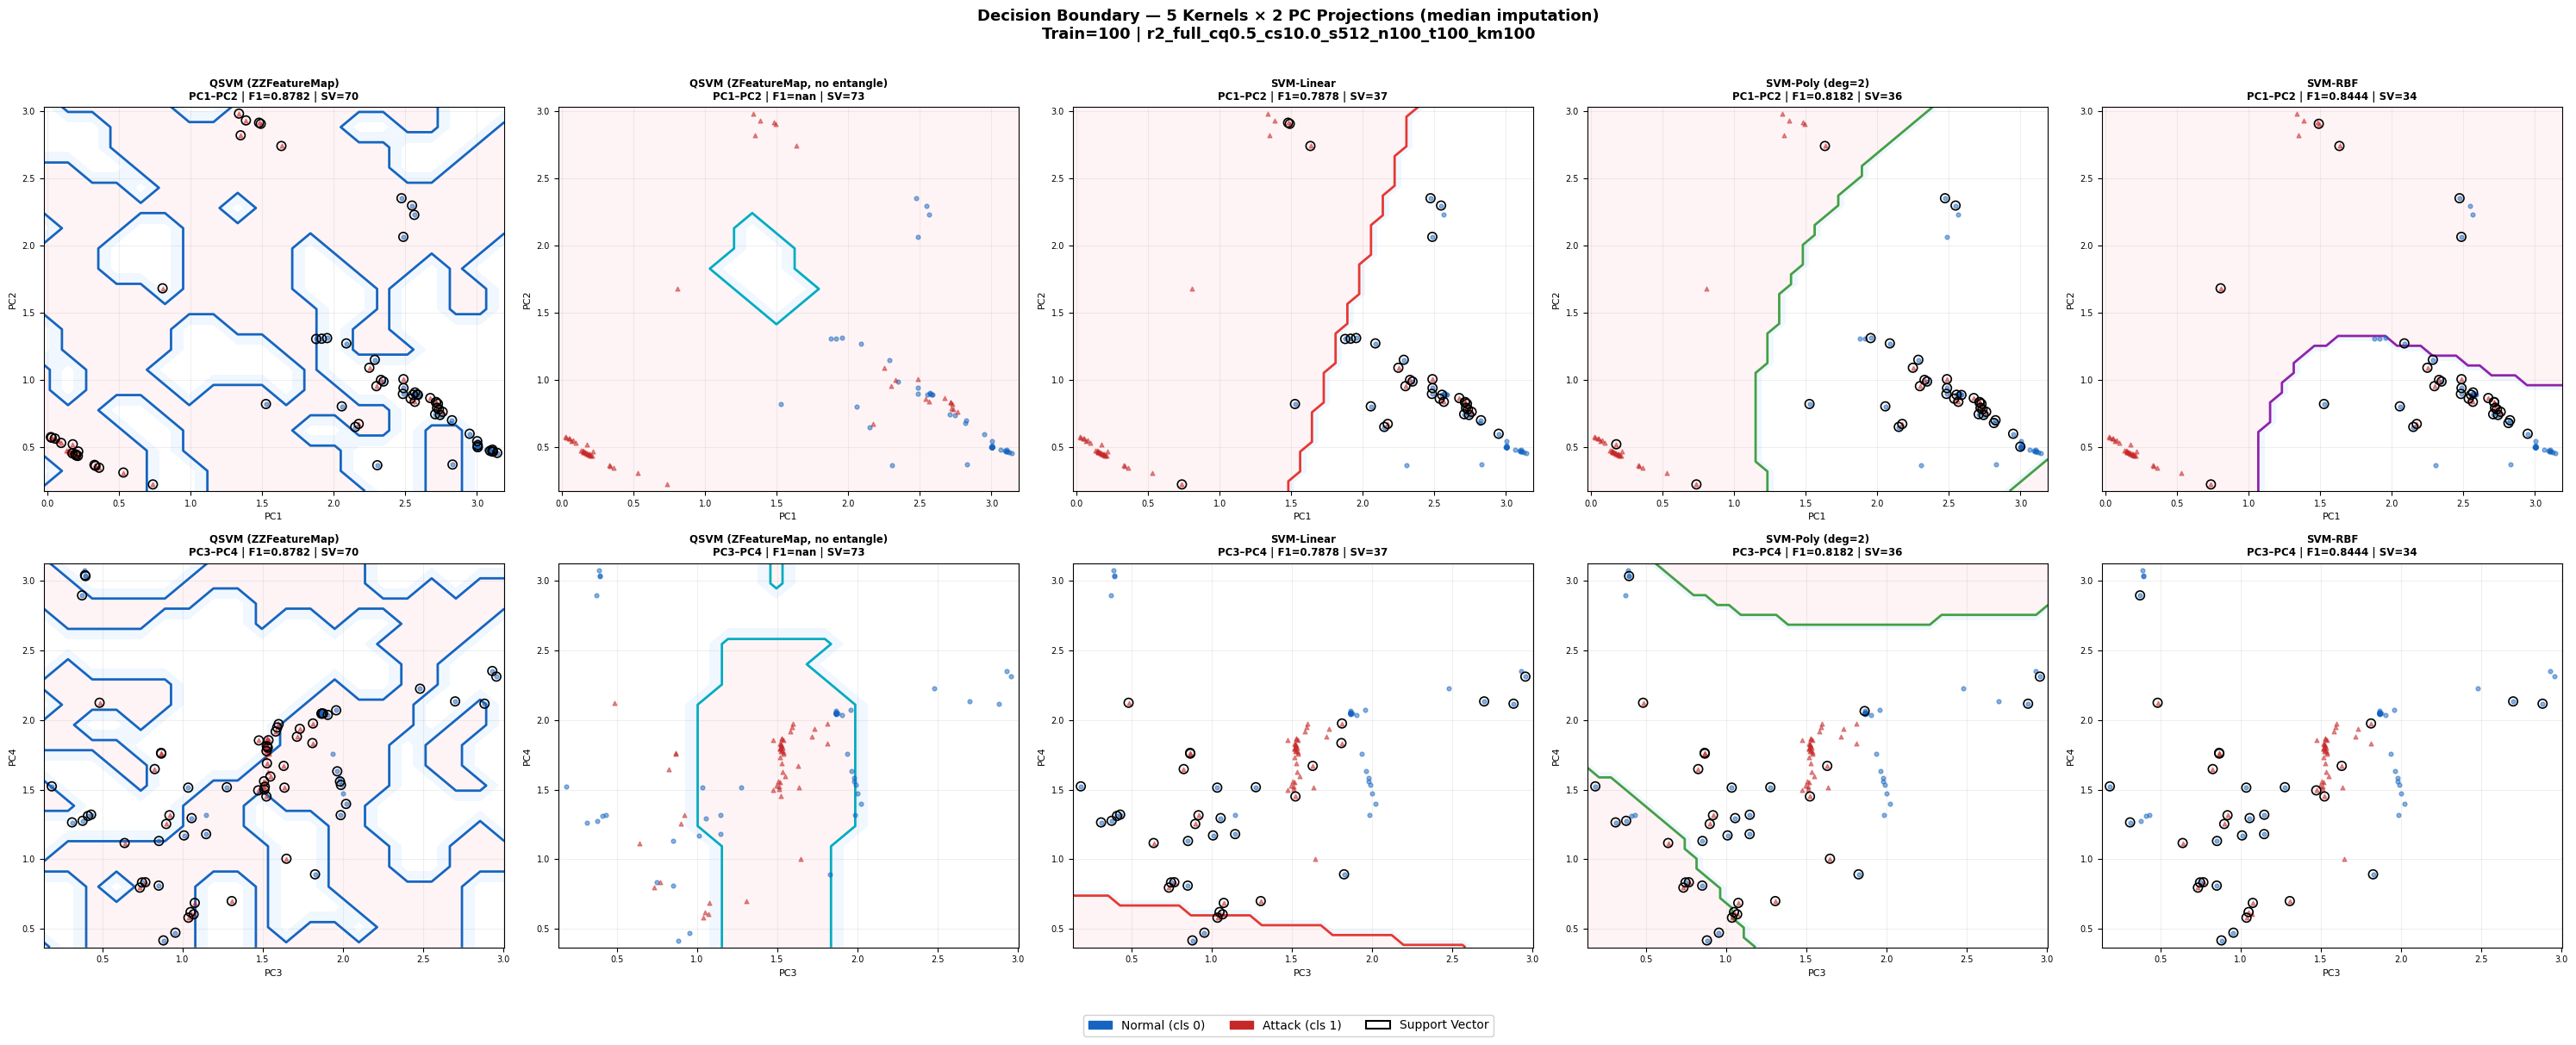

Đã lưu: ../data/processed_data/c3_decision_boundaries_all_r2_full_cq0.5_cs10.0_s512_n100_t100_km100.png


In [15]:
fig2, axes2 = plt.subplots(2, 5, figsize=(30, 12))
fig2.suptitle(
    'Decision Boundary — 5 Kernels × 2 PC Projections (median imputation)\n'
    f'Train={TRAIN_SIZE} | {CONFIG_TAG}',
    fontsize=13, fontweight='bold'
)

all_labels_db = ['quantum', 'quantum_z', 'linear', 'poly', 'rbf']

for col_idx, lbl in enumerate(all_labels_db):
    for row_idx, (pname, _i, _j, xl, yl) in enumerate(PC_PAIR_INFO):
        ax = axes2[row_idx, col_idx]
        if lbl not in db_grids:
            ax.text(0.5, 0.5, f'{lbl}\nnot available', ha='center', va='center',
                    transform=ax.transAxes)
            continue
        g = db_grids[lbl][pname]
        ax.contourf(g['xx'], g['yy'], g['Z'], alpha=0.22,
                    levels=[-0.5, 0.5, 1.5], colors=['#BBDEFB', '#FFCDD2'])
        ax.contour(g['xx'], g['yy'], g['Z'], levels=[0.5],
                   colors=[COLORS[lbl]], linewidths=2.0)
        for cls, marker, color in [(0, 'o', '#1565C0'), (1, '^', '#C62828')]:
            mask = y_train == cls
            ax.scatter(X_train[mask, _i], X_train[mask, _j],
                       c=color, marker=marker, s=12, alpha=0.5, zorder=3)
        # Support vector rings
        _svc_obj = svm_models.get(lbl) if lbl != 'quantum' else qsvm_model
        if _svc_obj is not None and hasattr(_svc_obj, 'support_'):
            sv_i = _svc_obj.support_
            ax.scatter(X_train[sv_i, _i], X_train[sv_i, _j],
                       s=55, facecolors='none', edgecolors='black',
                       linewidths=1.2, zorder=4)
        f1_v = (qsvm_result.get('f1', float('nan'))
                if lbl == 'quantum'
                else svm_results.get(lbl, {}).get('f1', float('nan')))
        nsv  = sv_analysis.get(lbl, {}).get('n_sv', 'N/A')
        ax.set_title(f'{LABEL_NAMES.get(lbl, lbl)}\n{xl}–{yl} | F1={f1_v:.4f} | SV={nsv}',
                     fontsize=8.5, fontweight='bold')
        ax.set_xlabel(xl, fontsize=8); ax.set_ylabel(yl, fontsize=8)
        ax.tick_params(labelsize=7)
        ax.grid(True, alpha=0.2)

leg_handles = [
    mpatches.Patch(color='#1565C0',   label='Normal (cls 0)'),
    mpatches.Patch(color='#C62828',   label='Attack (cls 1)'),
    mpatches.Patch(facecolor='none', edgecolor='black', linewidth=1.5, label='Support Vector'),
]
fig2.legend(handles=leg_handles, loc='lower center', ncol=3, fontsize=10,
            bbox_to_anchor=(0.5, -0.02), framealpha=0.9)
plt.tight_layout(rect=[0, 0.03, 1, 0.97])
fig2_path = f'{OUTPUT_DIR}/c3_decision_boundaries_all_{CONFIG_TAG}.png'
plt.savefig(fig2_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Đã lưu: {fig2_path}')

## 12c. Figure 3: Kernel Gram Matrices — Tất Cả 4 Kernels

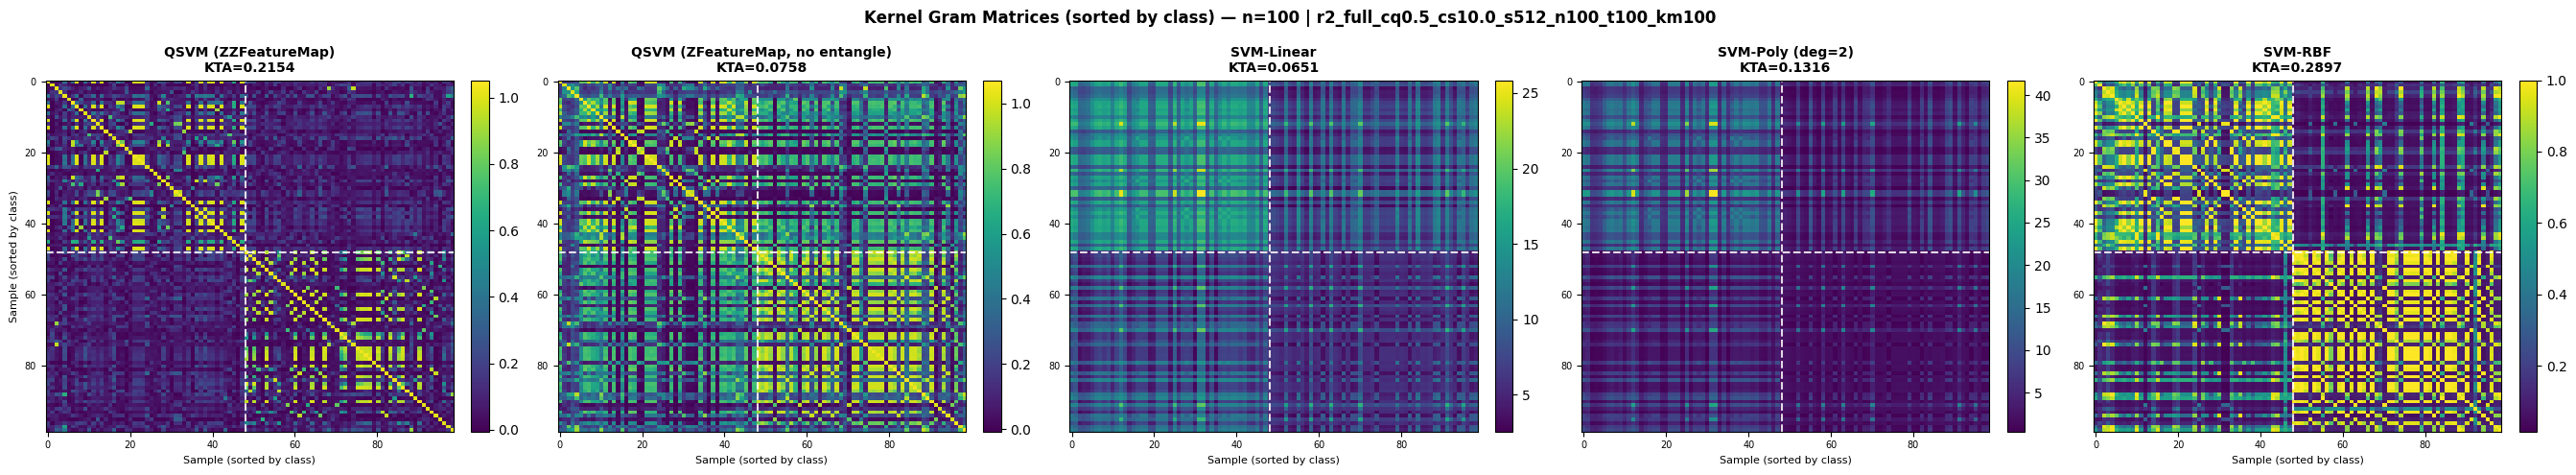

Đã lưu: ../data/processed_data/c3_kernel_matrices_all_r2_full_cq0.5_cs10.0_s512_n100_t100_km100.png


In [16]:
fig3, axes3 = plt.subplots(1, 5, figsize=(27, 5))
fig3.suptitle(
    f'Kernel Gram Matrices (sorted by class) — n={KM_SAMPLE_SIZE} | {CONFIG_TAG}',
    fontsize=12, fontweight='bold'
)

for col_idx, lbl in enumerate(['quantum', 'quantum_z', 'linear', 'poly', 'rbf']):
    ax  = axes3[col_idx]
    K   = km_matrices.get(lbl)
    if K is None:
        ax.text(0.5, 0.5, 'not available', ha='center', va='center',
                transform=ax.transAxes)
        continue
    K_s = K[sort_idx][:, sort_idx]
    im  = ax.imshow(K_s, aspect='auto', cmap='viridis',
                    vmin=K_s.min(), vmax=K_s.max(), interpolation='nearest')
    ax.axhline(boundary, color='white', lw=1.5, ls='--', alpha=0.85)
    ax.axvline(boundary, color='white', lw=1.5, ls='--', alpha=0.85)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    kta_v = kta_scores.get(lbl, float('nan'))
    ax.set_title(f'{LABEL_NAMES.get(lbl, lbl)}\nKTA={kta_v:.4f}', fontweight='bold', fontsize=10)
    ax.set_xlabel('Sample (sorted by class)', fontsize=8)
    if col_idx == 0:
        ax.set_ylabel('Sample (sorted by class)', fontsize=8)
    ax.tick_params(labelsize=7)

plt.tight_layout()
fig3_path = f'{OUTPUT_DIR}/c3_kernel_matrices_all_{CONFIG_TAG}.png'
plt.savefig(fig3_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Đã lưu: {fig3_path}')

## 13. Lưu Kết Quả

In [17]:
tag = CONFIG_TAG

# ── DataFrame metrics tổng hợp ────────────────────────────────────────────
rows = []
for lbl in ['quantum', 'quantum_z', 'linear', 'poly', 'rbf']:
    if lbl == 'quantum':
        f1_v  = qsvm_result.get('f1',  float('nan'))
        acc_v = qsvm_result.get('acc', float('nan'))
    elif lbl == 'quantum_z':
        f1_v  = qsvm_z_result.get('f1',  float('nan'))
        acc_v = qsvm_z_result.get('acc', float('nan'))
    else:
        f1_v  = svm_results.get(lbl, {}).get('f1',  float('nan'))
        acc_v = svm_results.get(lbl, {}).get('acc', float('nan'))
    kta_v = kta_scores.get(lbl, float('nan'))
    info  = sv_analysis.get(lbl, {})
    rows.append({
        'kernel'     : lbl,
        'f1_macro'   : f1_v,
        'accuracy'   : acc_v,
        'kta'        : kta_v,
        'n_sv'       : info.get('n_sv', float('nan')),
        'sv_ratio'   : info.get('sv_ratio', float('nan')),
        'margin_mean': info.get('margin_mean', float('nan')),
        'margin_std' : info.get('margin_std', float('nan')),
    })
results_df = pd.DataFrame(rows)

# ── Lưu CSV ───────────────────────────────────────────────────────────────
results_df.to_csv(f'{OUTPUT_DIR}/c3_kg_results_{tag}.csv', index=False)
pd.DataFrame(sorted_kta, columns=['kernel', 'kta']).to_csv(
    f'{OUTPUT_DIR}/c3_kta_scores_{tag}.csv', index=False)

# ── Lưu KTA Z kernel riêng (quantum_z) ───────────────────────────────────
kta_z_rows = [(lbl, kta_scores[lbl]) for lbl in ['quantum_z'] if lbl in kta_scores]
pd.DataFrame(kta_z_rows, columns=['kernel', 'kta']).to_csv(
    f'{OUTPUT_DIR}/c3_kta_z_scores_{CONFIG_TAG_Z}.csv', index=False)

pd.DataFrame(spearman_matrix, index=PC_LABELS, columns=PC_LABELS).to_csv(
    f'{OUTPUT_DIR}/c3_spearman_{tag}.csv')
pd.DataFrame(sv_analysis).T.drop(columns=['df_scores'], errors='ignore').to_csv(
    f'{OUTPUT_DIR}/c3_sv_analysis_{tag}.csv')

# ── Summary JSON ──────────────────────────────────────────────────────────
summary = {
    'config_tag'       : tag,
    'reps'             : REPS,
    'entanglement'     : ENTANGLEMENT,
    'C_QSVM'           : C_QSVM,
    'C_SVM'            : C_SVM,
    'shots'            : SHOTS,
    'poly_degree'      : POLY_DEGREE,
    'rbf_gamma'        : str(RBF_GAMMA),
    'train_size'       : TRAIN_SIZE,
    'test_size'        : TEST_SIZE,
    'km_sample_size'   : KM_SAMPLE_SIZE,
    'f1_qsvm'          : float(qsvm_result.get('f1',   float('nan'))),
    'f1_qsvm_z'        : float(qsvm_z_result.get('f1', float('nan'))),
    'kta_quantum'      : float(kta_scores.get('quantum',   float('nan'))),
    'kta_quantum_z'    : float(kta_scores.get('quantum_z', float('nan'))),
    'delta_kta_zz_z'   : float(kta_scores.get('quantum', 0) - kta_scores.get('quantum_z', 0)),
    'kta_linear'       : float(kta_scores.get('linear',  float('nan'))),
    'kta_poly'         : float(kta_scores.get('poly',    float('nan'))),
    'kta_rbf'          : float(kta_scores.get('rbf',     float('nan'))),
    'best_kta_kernel'  : best_kernel,
    'best_kta_value'   : float(best_kta_val),
    'n_sv_qsvm'        : sv_analysis.get('quantum',   {}).get('n_sv', None),
    'n_sv_qsvm_z'      : sv_analysis.get('quantum_z', {}).get('n_sv', None),
    'n_sv_linear'      : sv_analysis.get('linear',    {}).get('n_sv', None),
    'n_sv_poly'        : sv_analysis.get('poly',      {}).get('n_sv', None),
    'n_sv_rbf'         : sv_analysis.get('rbf',       {}).get('n_sv', None),
    'f1_svm_linear'    : float(svm_results.get('linear', {}).get('f1', float('nan'))),
    'f1_svm_poly'      : float(svm_results.get('poly',   {}).get('f1', float('nan'))),
    'f1_svm_rbf'       : float(svm_results.get('rbf',    {}).get('f1', float('nan'))),
}
summary_path = f'{OUTPUT_DIR}/c3_summary_{tag}.json'
with open(summary_path, 'w') as fp:
    json.dump(summary, fp, indent=2)

# ── Thêm scaler comparison vào summary JSON ───────────────────────────────
for lbl in ['linear', 'poly', 'rbf']:
    for sc in ['mm', 'std']:
        key = f'{lbl}_{sc}'
        res = svm_results.get(key, {})
        summary[f'f1_svm_{lbl}_{sc}']  = float(res.get('f1',  float('nan')))
        summary[f'acc_svm_{lbl}_{sc}'] = float(res.get('acc', float('nan')))
with open(summary_path, 'w') as fp:
    json.dump(summary, fp, indent=2)

# ── Lưu comparison DataFrame ──────────────────────────────────────────────
cmp_df[['Model', 'Scaler', 'F1_macro', 'Accuracy', 'n_SV']].to_csv(
    f'{OUTPUT_DIR}/c3_performance_comparison_{tag}.csv', index=False)

# ── In danh sách file đã lưu ──────────────────────────────────────────────
print('=== ĐÃ LƯU ===')
for fname, info in [
    (f'c3_kg_results_{tag}.csv',              'Metrics tổng hợp 5 kernels'),
    (f'c3_kta_scores_{tag}.csv',              'KTA ZZ kernels'),
    (f'c3_kta_z_scores_{CONFIG_TAG_Z}.csv',   'KTA Z kernel (quantum_z)'),
    (f'c3_performance_comparison_{tag}.csv',  'F1 & Acc comparison table'),
    (f'c3_performance_comparison_{tag}.png',  'Figure 4: F1 & Acc bar chart'),
    (f'c3_spearman_{tag}.csv',                'Spearman correlation matrix'),
    (f'c3_sv_analysis_{tag}.csv',             'Support vector analysis'),
    (f'c3_kernel_geometry_{tag}.png',         'Figure 1: Overview (8 plots)'),
    (f'c3_decision_boundaries_all_{tag}.png', 'Figure 2: Decision boundary 5×2'),
    (f'c3_kernel_matrices_all_{tag}.png',     'Figure 3: Gram matrices 5 kernels'),
    (f'c3_summary_{tag}.json',                'Summary JSON'),
]:
    status = '✓' if os.path.exists(f'{OUTPUT_DIR}/{fname}') else '✗'
    print(f'  {status} {fname:<55} {info}')

print(f'\nModel cache      : {QSVM_MODEL_DIR}/')
print(f'Result cache dir : {RESULTS_CACHE_DIR}/')
cached_files = [f for f in os.listdir(RESULTS_CACHE_DIR) if f.endswith(('.json', '.npz'))]
print(f'  {len(cached_files)} file(s) cached')

display(
    results_df.style
    .format({'f1_macro': '{:.4f}', 'accuracy': '{:.4f}', 'kta': '{:.6f}',
             'n_sv': '{:.0f}', 'sv_ratio': '{:.3f}',
             'margin_mean': '{:.4f}', 'margin_std': '{:.4f}'})
    .highlight_max(subset=['f1_macro', 'accuracy', 'kta'], color='#c8e6c9')
    .highlight_min(subset=['n_sv', 'sv_ratio'],             color='#fff9c4')
    .hide(axis='index')
)

=== ĐÃ LƯU ===
  ✓ c3_kg_results_r2_full_cq0.5_cs10.0_s512_n100_t100_km100.csv Metrics tổng hợp 5 kernels
  ✓ c3_kta_scores_r2_full_cq0.5_cs10.0_s512_n100_t100_km100.csv KTA ZZ kernels
  ✓ c3_kta_z_scores_z_r2_cq0.5_cs10.0_s512_n100_t100_km100.csv KTA Z kernel (quantum_z)
  ✓ c3_performance_comparison_r2_full_cq0.5_cs10.0_s512_n100_t100_km100.csv F1 & Acc comparison table
  ✓ c3_performance_comparison_r2_full_cq0.5_cs10.0_s512_n100_t100_km100.png Figure 4: F1 & Acc bar chart
  ✓ c3_spearman_r2_full_cq0.5_cs10.0_s512_n100_t100_km100.csv Spearman correlation matrix
  ✓ c3_sv_analysis_r2_full_cq0.5_cs10.0_s512_n100_t100_km100.csv Support vector analysis
  ✓ c3_kernel_geometry_r2_full_cq0.5_cs10.0_s512_n100_t100_km100.png Figure 1: Overview (8 plots)
  ✓ c3_decision_boundaries_all_r2_full_cq0.5_cs10.0_s512_n100_t100_km100.png Figure 2: Decision boundary 5×2
  ✓ c3_kernel_matrices_all_r2_full_cq0.5_cs10.0_s512_n100_t100_km100.png Figure 3: Gram matrices 5 kernels
  ✓ c3_summary_r2_full_cq0.

kernel,f1_macro,accuracy,kta,n_sv,sv_ratio,margin_mean,margin_std
quantum,0.8782,0.8788,0.215365,70,0.700,0.8509,0.2862
quantum_z,0.8182,0.8182,0.075787,73,0.730,0.8201,0.3622
linear,0.7878,0.7879,0.065091,37,0.370,1.2741,0.6316
poly,0.8182,0.8182,0.131643,36,0.360,1.6111,1.1224
rbf,0.8444,0.8485,0.289659,34,0.340,1.4073,0.5942


## 14. Summary — Contribution 3

In [18]:
q_f1   = qsvm_result.get('f1',    float('nan'))
qz_f1  = qsvm_z_result.get('f1',  float('nan'))
q_kta  = kta_scores.get('quantum',   float('nan'))
qz_kta = kta_scores.get('quantum_z', float('nan'))
r_kta  = kta_scores.get('rbf',       float('nan'))
l_kta  = kta_scores.get('linear',    float('nan'))
p_kta  = kta_scores.get('poly',      float('nan'))

print('=' * 72)
print('  CONTRIBUTION 3 — KERNEL GEOMETRY & DECISION BOUNDARY (NSL-KDD)')
print('=' * 72)
print(f'  CONFIG_TAG   : {CONFIG_TAG}')
print(f'  Circuit ZZ   : ZZFeatureMap, {N_QUBITS} qubits, reps={REPS}, entanglement={ENTANGLEMENT}')
print(f'  Circuit Z    : ZFeatureMap,  {N_QUBITS} qubits, reps={REPS_Z} (no entanglement)')
print(f'  Train/Test   : {TRAIN_SIZE} / {TEST_SIZE} | KM sample: {KM_SAMPLE_SIZE}')
print()

print('  [1] Performance Comparison (F1-macro)')
print(f'      QSVM (ZZFeatureMap): {q_f1:.4f}')
for lbl in ['linear', 'poly', 'rbf']:
    f1_v = svm_results.get(lbl, {}).get('f1', float('nan'))
    print(f'      SVM-{lbl:6s}        : {f1_v:.4f}  (Δ QSVM = {q_f1 - f1_v:+.4f})')

print()
print('  [2] Kernel Target Alignment (KTA)')
for lbl, kta in sorted(kta_scores.items(), key=lambda x: x[1], reverse=True):
    marker = '  ← best' if lbl == best_kernel else ''
    print(f'      {lbl:10s}: {kta:.6f}{marker}')
print(f'  Δ KTA (quantum-linear): {q_kta - l_kta:+.6f}')
print(f'  Δ KTA (quantum-poly)  : {q_kta - p_kta:+.6f}')
print(f'  Δ KTA (quantum-rbf)   : {q_kta - r_kta:+.6f}')

print()
print('  [3] Support Vector Analysis')
for lbl in ['quantum', 'quantum_z', 'linear', 'poly', 'rbf']:
    info = sv_analysis.get(lbl, {})
    nsv  = info.get('n_sv', 'N/A')
    svr  = info.get('sv_ratio', float('nan'))
    mm   = info.get('margin_mean', float('nan'))
    sv0, sv1 = info.get('sv_class_dist', [float('nan'), float('nan')])
    print(f'      {lbl:10s}: n_SV={nsv}  ratio={svr:.2f}  '
          f'margin_μ={mm:.4f}  [cls0={sv0}, cls1={sv1}]')

print()
print('  [4] Spearman Correlation (C1→C2→C3 evidence chain)')
for i in range(N_QUBITS):
    for j in range(i + 1, N_QUBITS):
        sp = spearman_matrix[i, j]
        pe = pearson_matrix[i, j]
        if abs(sp) > 0.05:
            print(f'      {PC_LABELS[i]}–{PC_LABELS[j]}: '
                  f'Pearson={pe:+.4f}  Spearman={sp:+.4f}  '
                  f'nonlinear={abs(sp)-abs(pe):+.4f}')

print()
print('  [5] Decision Boundary')
print(f'      Projected onto PC1–PC2 và PC3–PC4 (median imputation, grid=60×60)')
print(f'      4 kernels × 2 PC pairs → 8 boundary plots (Figure 2)')

print()
print('  [KEY FINDING]')
if q_kta > r_kta and q_kta > l_kta:
    print(f'      QSVM có KTA cao nhất ({q_kta:.4f}) → quantum kernel geometry')
    print(f'      tương thích tốt nhất với label structure của NSL-KDD.')
elif q_kta > r_kta:
    print(f'      QSVM KTA ({q_kta:.4f}) > SVM-RBF KTA ({r_kta:.4f})')
    print(f'      Quantum kernel thể hiện block structure rõ hơn RBF.')
else:
    print(f'      Best KTA: {best_kernel} ({best_kta_val:.4f}). QSVM KTA={q_kta:.4f}.')
    print(f'      Thử tăng REPS hoặc điều chỉnh C_QSVM để cải thiện kernel alignment.')
print('=' * 72)
print(f'\nResult cache : {RESULTS_CACHE_DIR}')
print(f'Summary JSON : {OUTPUT_DIR}/c3_summary_{CONFIG_TAG}.json')

  CONTRIBUTION 3 — KERNEL GEOMETRY & DECISION BOUNDARY (NSL-KDD)
  CONFIG_TAG   : r2_full_cq0.5_cs10.0_s512_n100_t100_km100
  Circuit ZZ   : ZZFeatureMap, 4 qubits, reps=2, entanglement=full
  Circuit Z    : ZFeatureMap,  4 qubits, reps=2 (no entanglement)
  Train/Test   : 100 / 100 | KM sample: 100

  [1] Performance Comparison (F1-macro)
      QSVM (ZZFeatureMap): 0.8782
      SVM-linear        : 0.7878  (Δ QSVM = +0.0904)
      SVM-poly          : 0.8182  (Δ QSVM = +0.0600)
      SVM-rbf           : 0.8444  (Δ QSVM = +0.0338)

  [2] Kernel Target Alignment (KTA)
      rbf       : 0.289659  ← best
      quantum   : 0.215365
      poly      : 0.131643
      quantum_z : 0.075787
      linear    : 0.065091
  Δ KTA (quantum-linear): +0.150274
  Δ KTA (quantum-poly)  : +0.083722
  Δ KTA (quantum-rbf)   : -0.074294

  [3] Support Vector Analysis
      quantum   : n_SV=70  ratio=0.70  margin_μ=0.8509  [cls0=34, cls1=36]
      quantum_z : n_SV=73  ratio=0.73  margin_μ=0.8201  [cls0=37, cls1=